# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Randra Ferdian Saputra
- Email: ferdianrandra@gmail.com
- Id Dicoding:Randra Ferdian

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# --- Standard Libraries & Utilities ---
import os
import math
import joblib
from collections import Counter

# --- Data Manipulation & Analysis ---
import numpy as np
import pandas as pd

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning: Preprocessing & Pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

# --- Machine Learning: Model Selection ---
from sklearn.model_selection import train_test_split, cross_val_score

# --- Machine Learning: Algorithms ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier
)
from xgboost import XGBClassifier

# --- Machine Learning: Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc,
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

### Menyiapkan data yang akan diguankan

In [2]:
data_path = 'Datasets/data.csv'
df = pd.read_csv(data_path, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

### Data Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

### Missing Value & Duplikat

In [4]:
#missing Values
missing_values = df.isnull().sum()
print("Total Missing Values:\n", missing_values)

print('\n')
print("===============================")
print('\n')

#Duplicate Data
duplicate_data = df.duplicated().sum()
print("Total Data Duplikat:", duplicate_data)

Total Missing Values:
 Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment          

### Value setiap Fitur

In [5]:
# value every column
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"Unique values in '{column}': {unique_values}")
    print(df[column].value_counts().sort_index())
    print('================================')

Unique values in 'Marital_status': 6
Marital_status
1    3919
2     379
3       4
4      91
5      25
6       6
Name: count, dtype: int64
Unique values in 'Application_mode': 18
Application_mode
1     1708
2        3
5       16
7      139
10      10
15      30
16      38
17     872
18     124
26       1
27       1
39     785
42      77
43     312
44     213
51      59
53      35
57       1
Name: count, dtype: int64
Unique values in 'Application_order': 8
Application_order
0       1
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
Name: count, dtype: int64
Unique values in 'Course': 17
Course
33       12
171     215
8014    215
9003    210
9070    226
9085    337
9119    170
9130    141
9147    380
9238    355
9254    252
9500    766
9556     86
9670    268
9773    331
9853    192
9991    268
Name: count, dtype: int64
Unique values in 'Daytime_evening_attendance': 2
Daytime_evening_attendance
0     483
1    3941
Name: count, dtype: int64
Unique values in 'Previous_q

### Pengelompokan Data

In [6]:
categorical_features = [
    'Marital_status', 'Nacionality', 'International', 'Gender', 'Application_mode', 'Course', 
    'Previous_qualification', 'Daytime_evening_attendance', 'Mothers_qualification', 
    'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 
    'Displaced', 'Educational_special_needs', 'Debtor', 
    'Tuition_fees_up_to_date', 'Scholarship_holder',
]

numerical_features = [
    'Application_order', 'Age_at_enrollment', 'Previous_qualification_grade', 
    'Admission_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP',
    'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations'
]
target_feature = ['Status']

def check_features(df, cat_feats, num_feats, target_feat):
    """
    Fungsi untuk memvalidasi apakah semua kolom di DataFrame sudah terpetakan 
    ke dalam list fitur (kategorik/numerik/target).
    """
    
    all_defined = cat_feats + num_feats + target_feat
    missing_in_lists = [col for col in df.columns if col not in all_defined]
    missing_in_df = [col for col in all_defined if col not in df.columns]
    duplicates = [item for item, count in Counter(all_defined).items() if count > 1]
    
    print("=== HASIL PENGECEKAN FITUR ===")
    if not missing_in_lists and not missing_in_df and not duplicates:
        print("✅ SEMPURNA: Semua fitur sudah terpetakan dengan benar.")
    else:
        if missing_in_lists:
            print(f"⚠️ Ketinggalan (Ada di data tapi belum masuk list): {missing_in_lists}")
        if missing_in_df:
            print(f"❌ Salah Nama/Typo (Ada di list tapi tidak ada di data): {missing_in_df}")
        if duplicates:
            print(f"🔄 Duplikat (Masuk ke list lebih dari satu kali): {duplicates}")
    
    print("==============================")

check_features(df, categorical_features, numerical_features, target_feature)

=== HASIL PENGECEKAN FITUR ===
✅ SEMPURNA: Semua fitur sudah terpetakan dengan benar.


### EDA fitur Kategorikal

C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3344967316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3344967316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3344967316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3344967316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

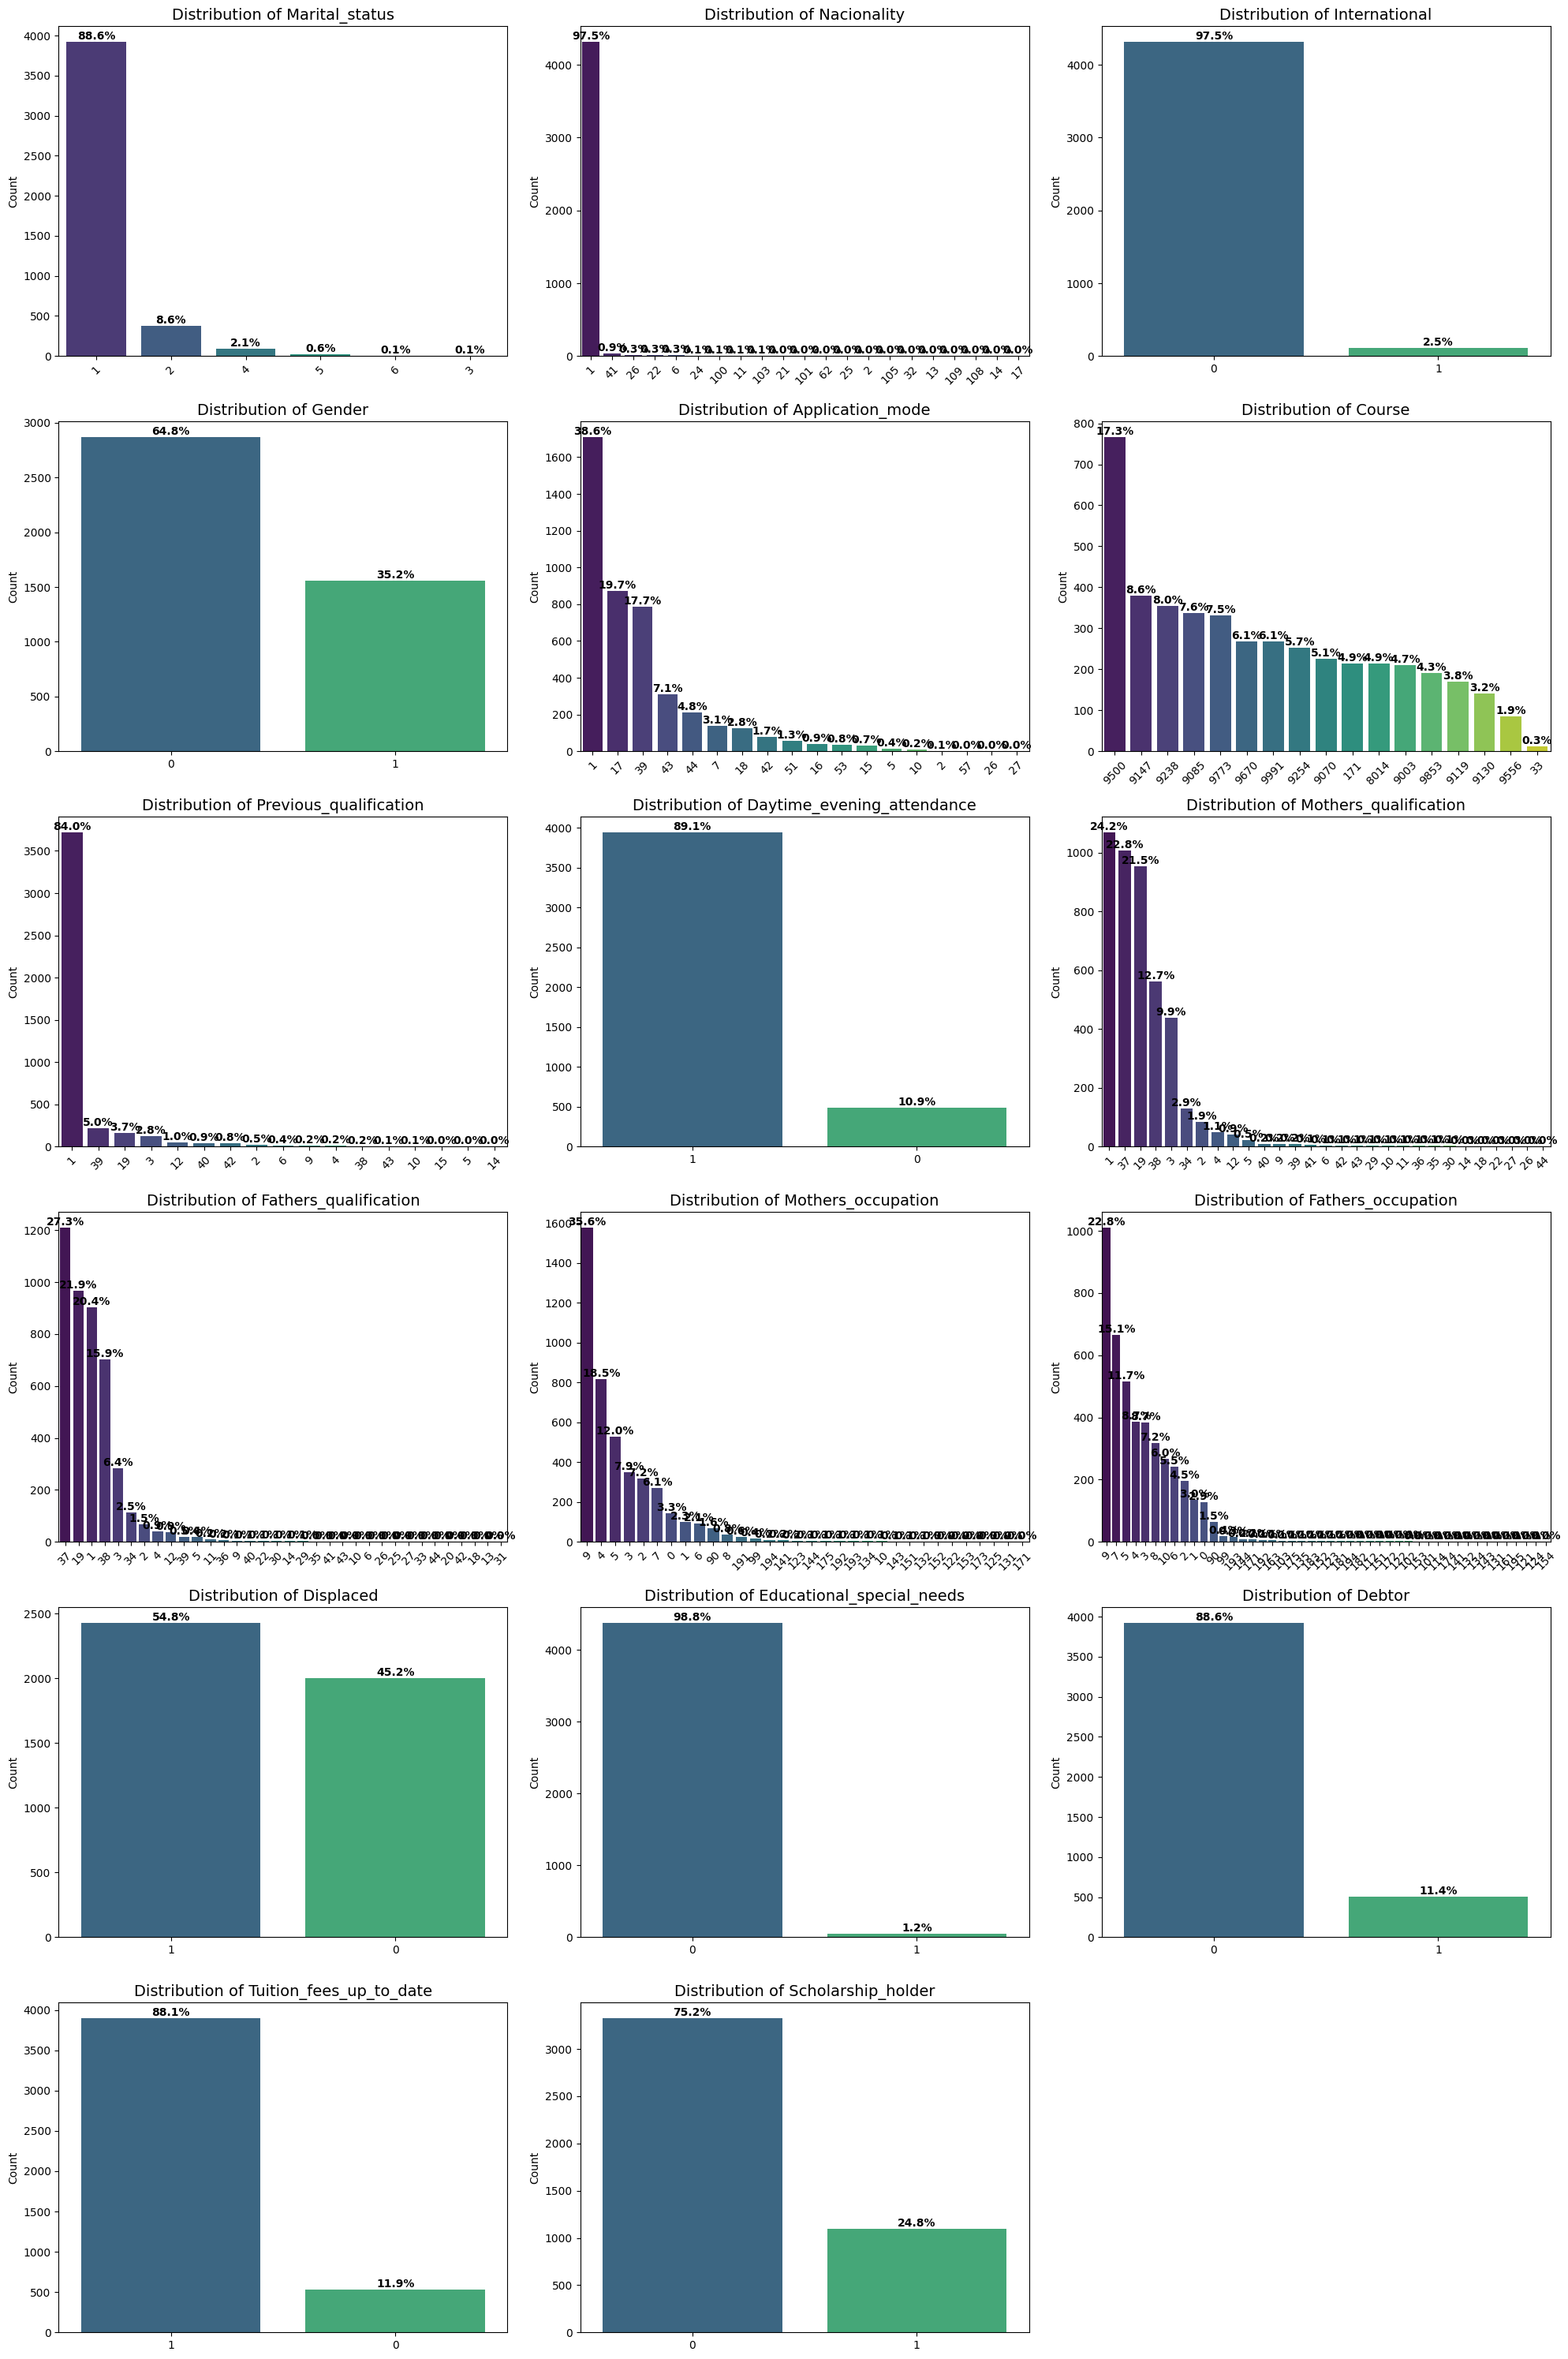

In [7]:
n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)


fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten() 

for i, col in enumerate(categorical_features):
    ax = axes[i]
    total = len(df[col]) 
    
    sns.countplot(
        data=df, 
        x=col, 
        ax=ax, 
        order=df[col].value_counts().index,
        palette='viridis'
    )
    
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    
    if df[col].nunique() > 5:
        ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### EDA bivariate Kategorik vs Target

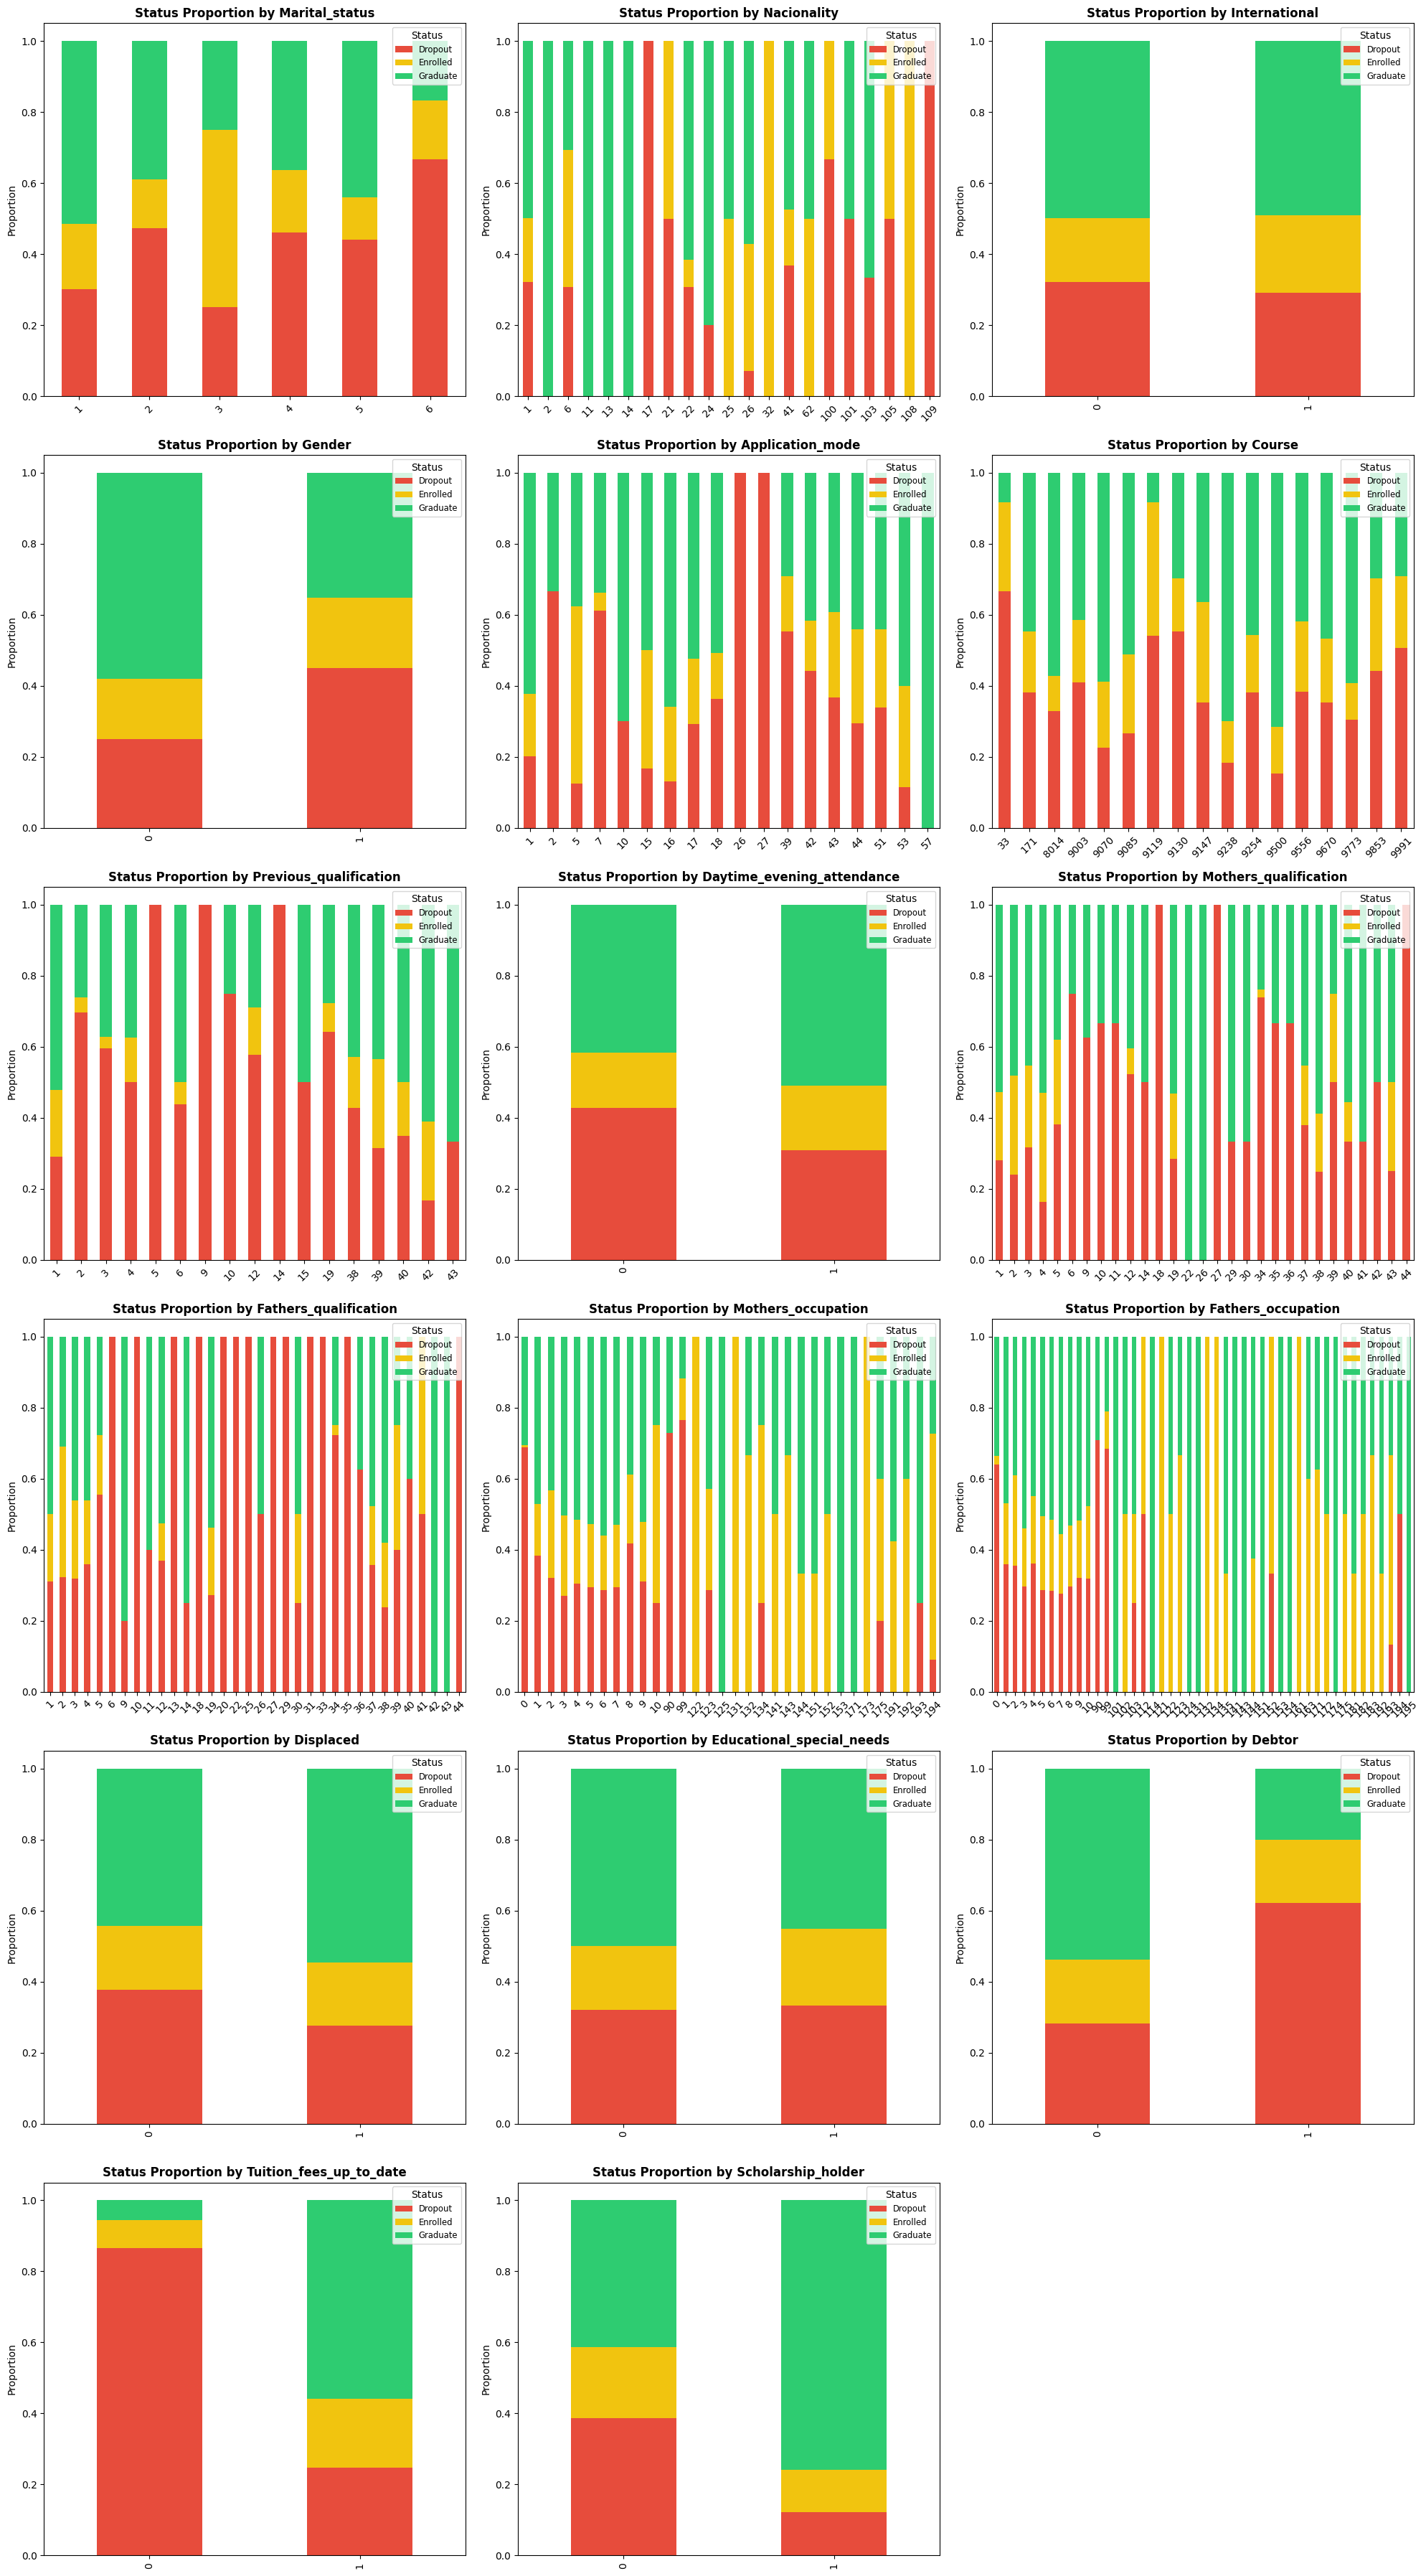

In [8]:
n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    cross_tab = pd.crosstab(df[col], df['Status'], normalize='index')
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#e74c3c', '#f1c40f', '#2ecc71'])
    
    axes[i].set_title(f'Status Proportion by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Status', loc='upper right', fontsize='small')
    if df[col].nunique() > 5:
        axes[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### EDA Fitur Numerik

In [9]:
df[numerical_features].describe()

,Application_order,Age_at_enrollment,Previous_qualification_grade,Admission_grade,Unemployment_rate,Inflation_rate,GDP,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,23.265145,132.613314,126.978119,11.566139,1.228029,0.001969,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,1.313793,7.587816,13.188332,14.482001,2.663850,1.382711,2.269935,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,0.000000,17.000000,95.000000,95.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,19.000000,125.000000,117.900000,9.400000,0.300000,-1.700000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,1.000000,20.000000,133.100000,126.100000,11.100000,1.400000,0.320000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,2.000000,25.000000,140.000000,134.800000,13.900000,2.600000,1.790000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,9.000000,70.000000,190.000000,190.000000,16.200000,3.700000,3.510000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


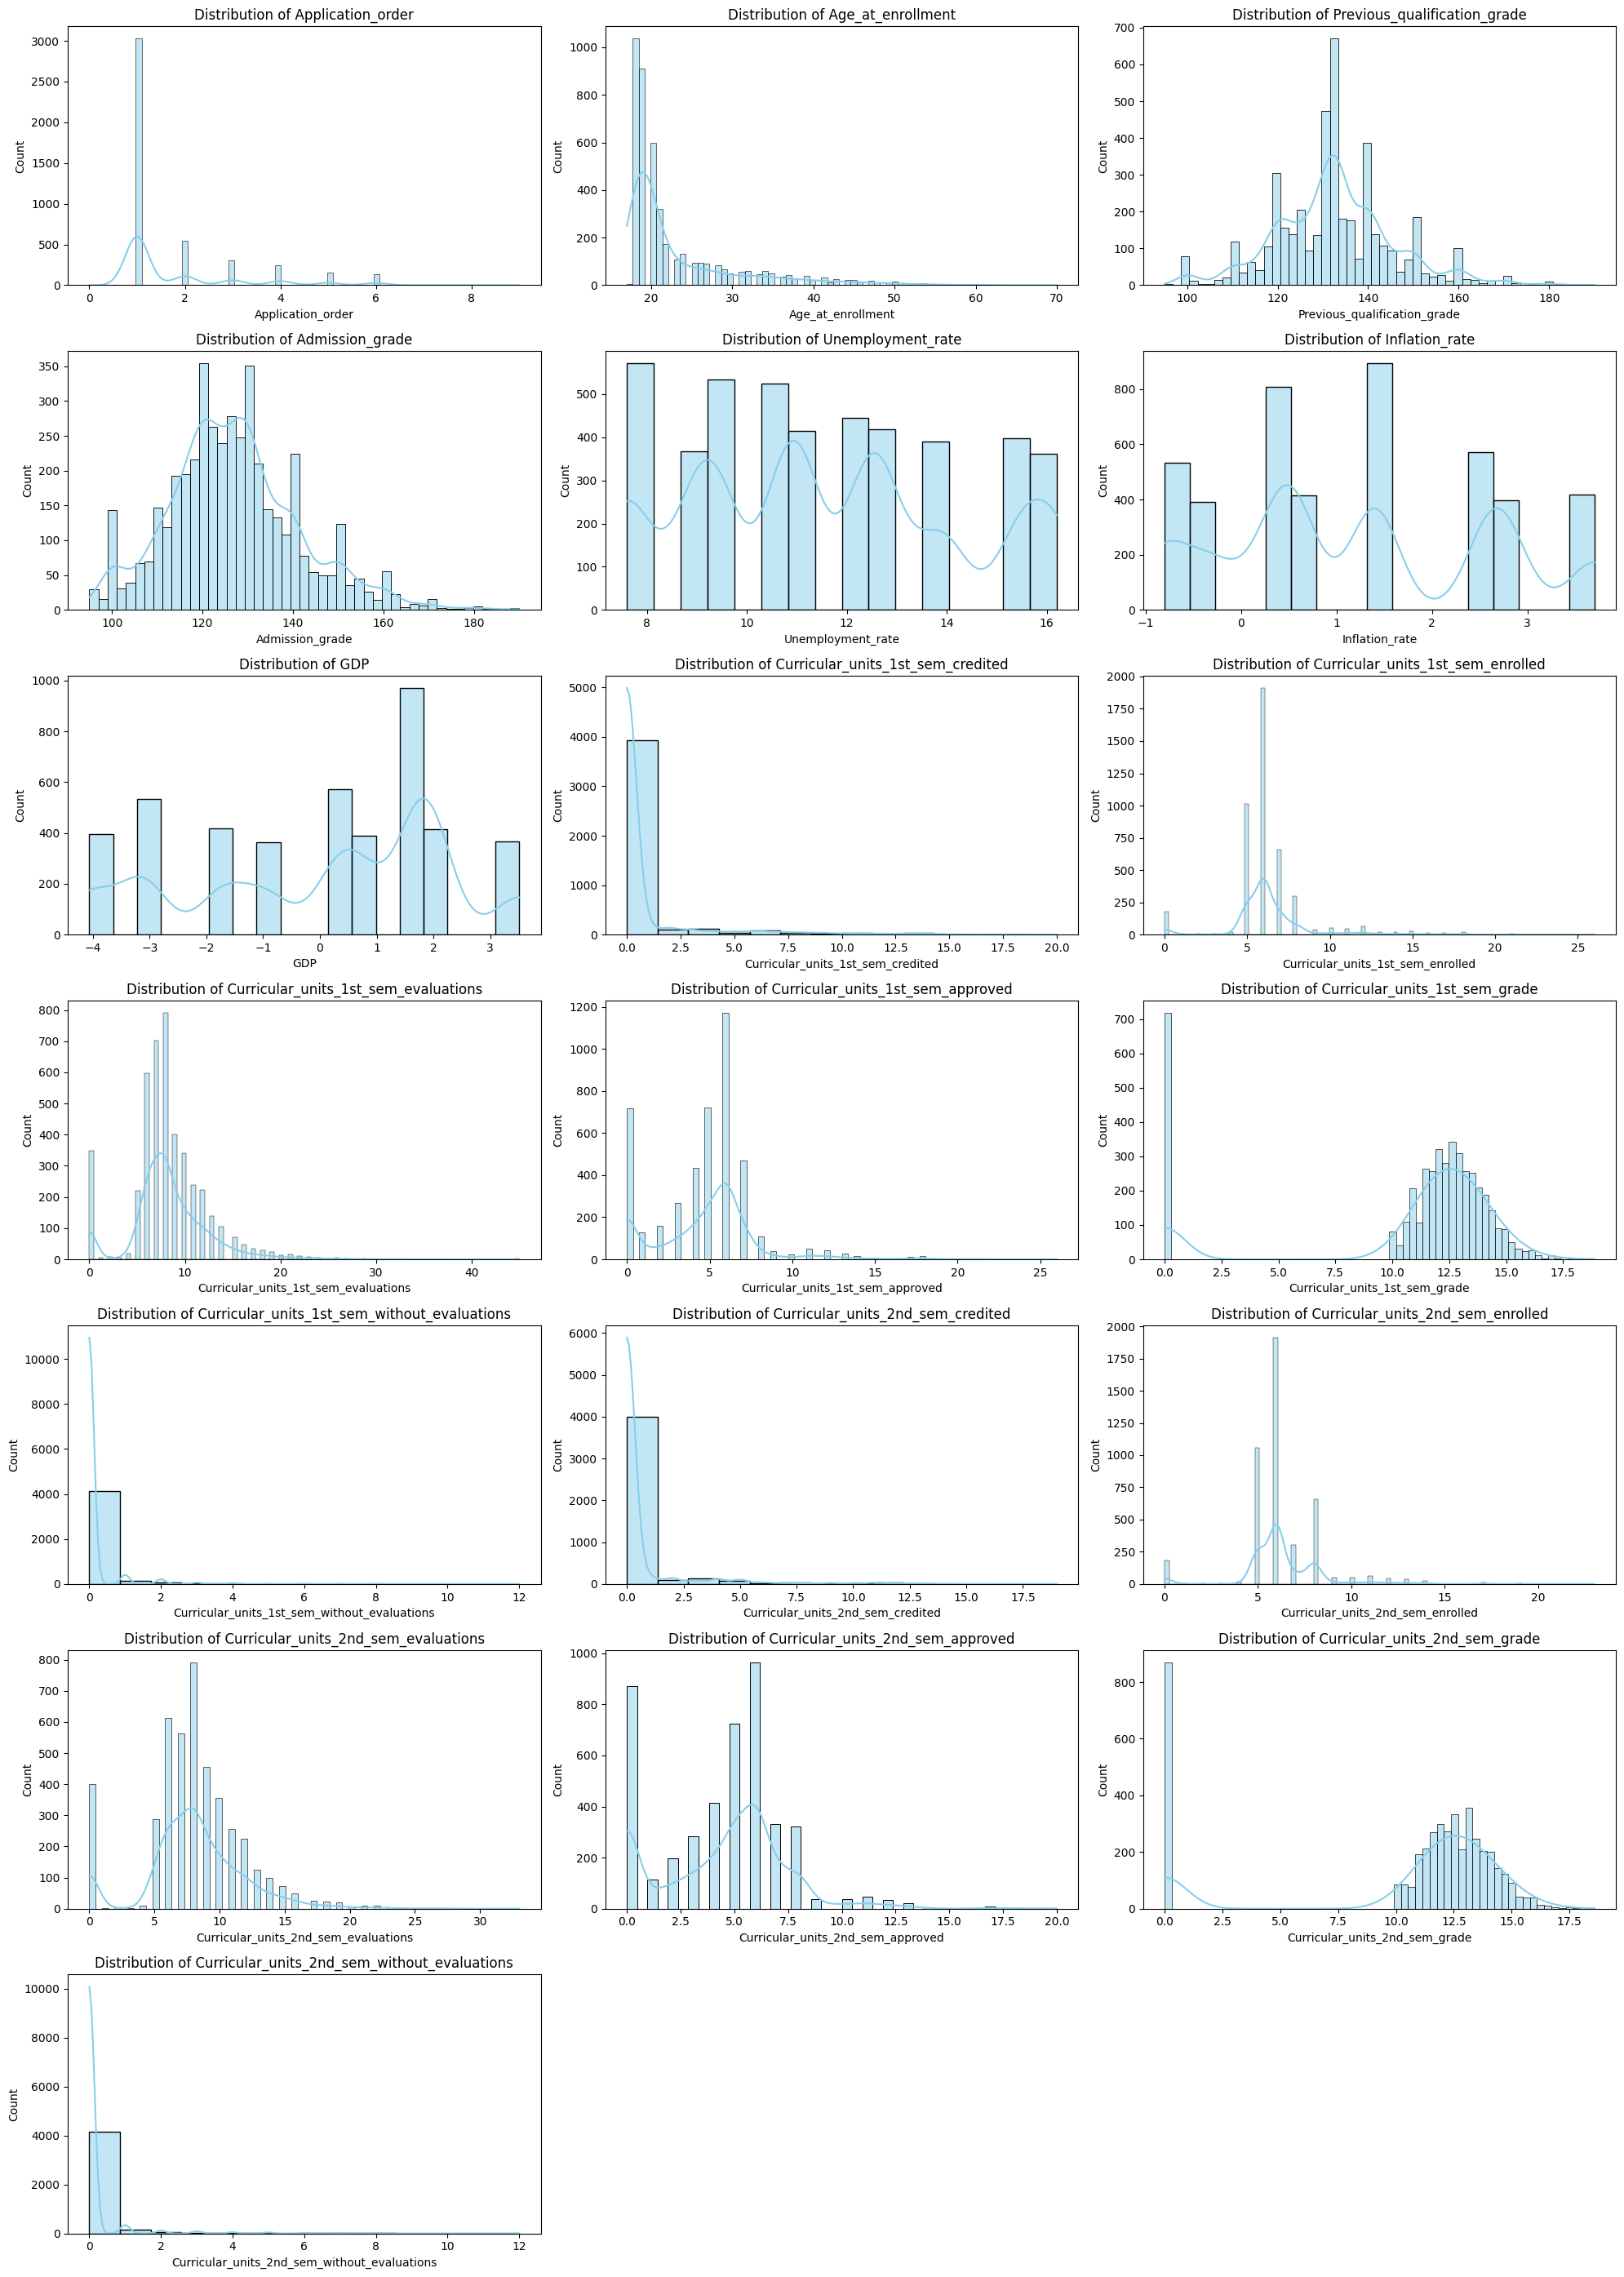

In [10]:
n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

# Menghapus axis kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### EDA Outlier 

C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3403682759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='viridis')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3403682759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='viridis')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3403682759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='viridis')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3403682759.py:7: 

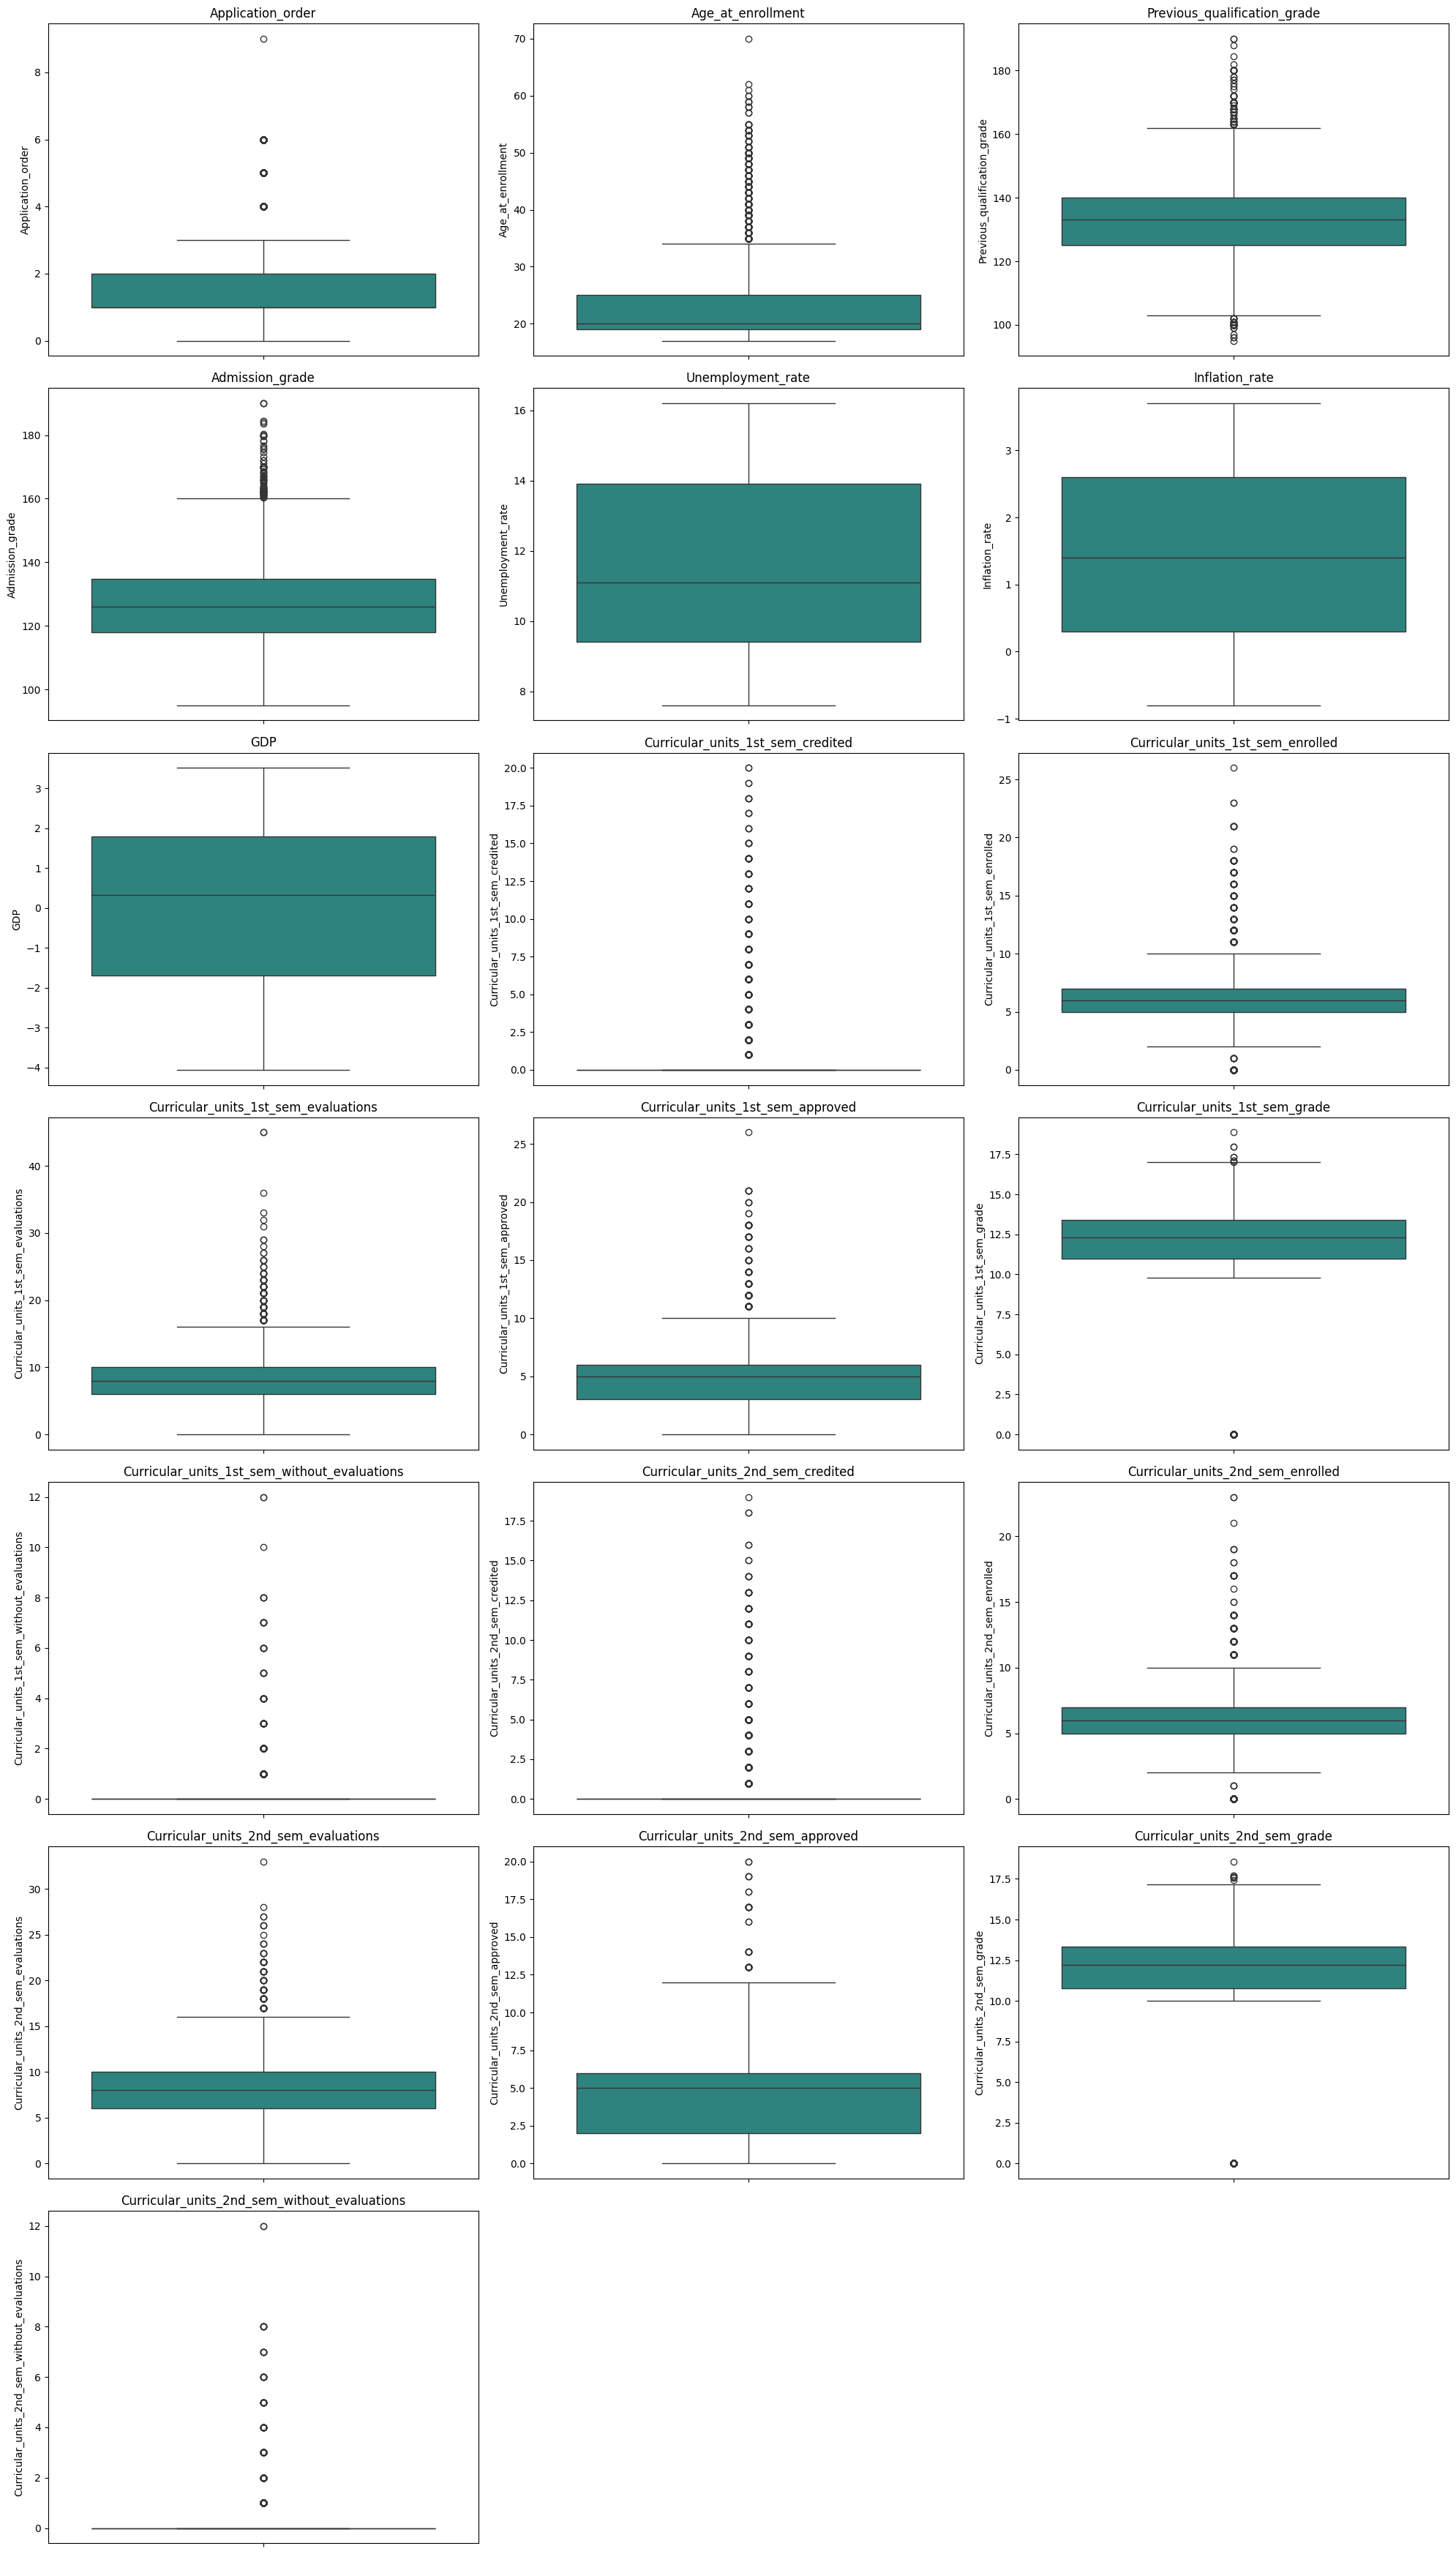

In [11]:
n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### EDA Bivariate Numerik vs Target

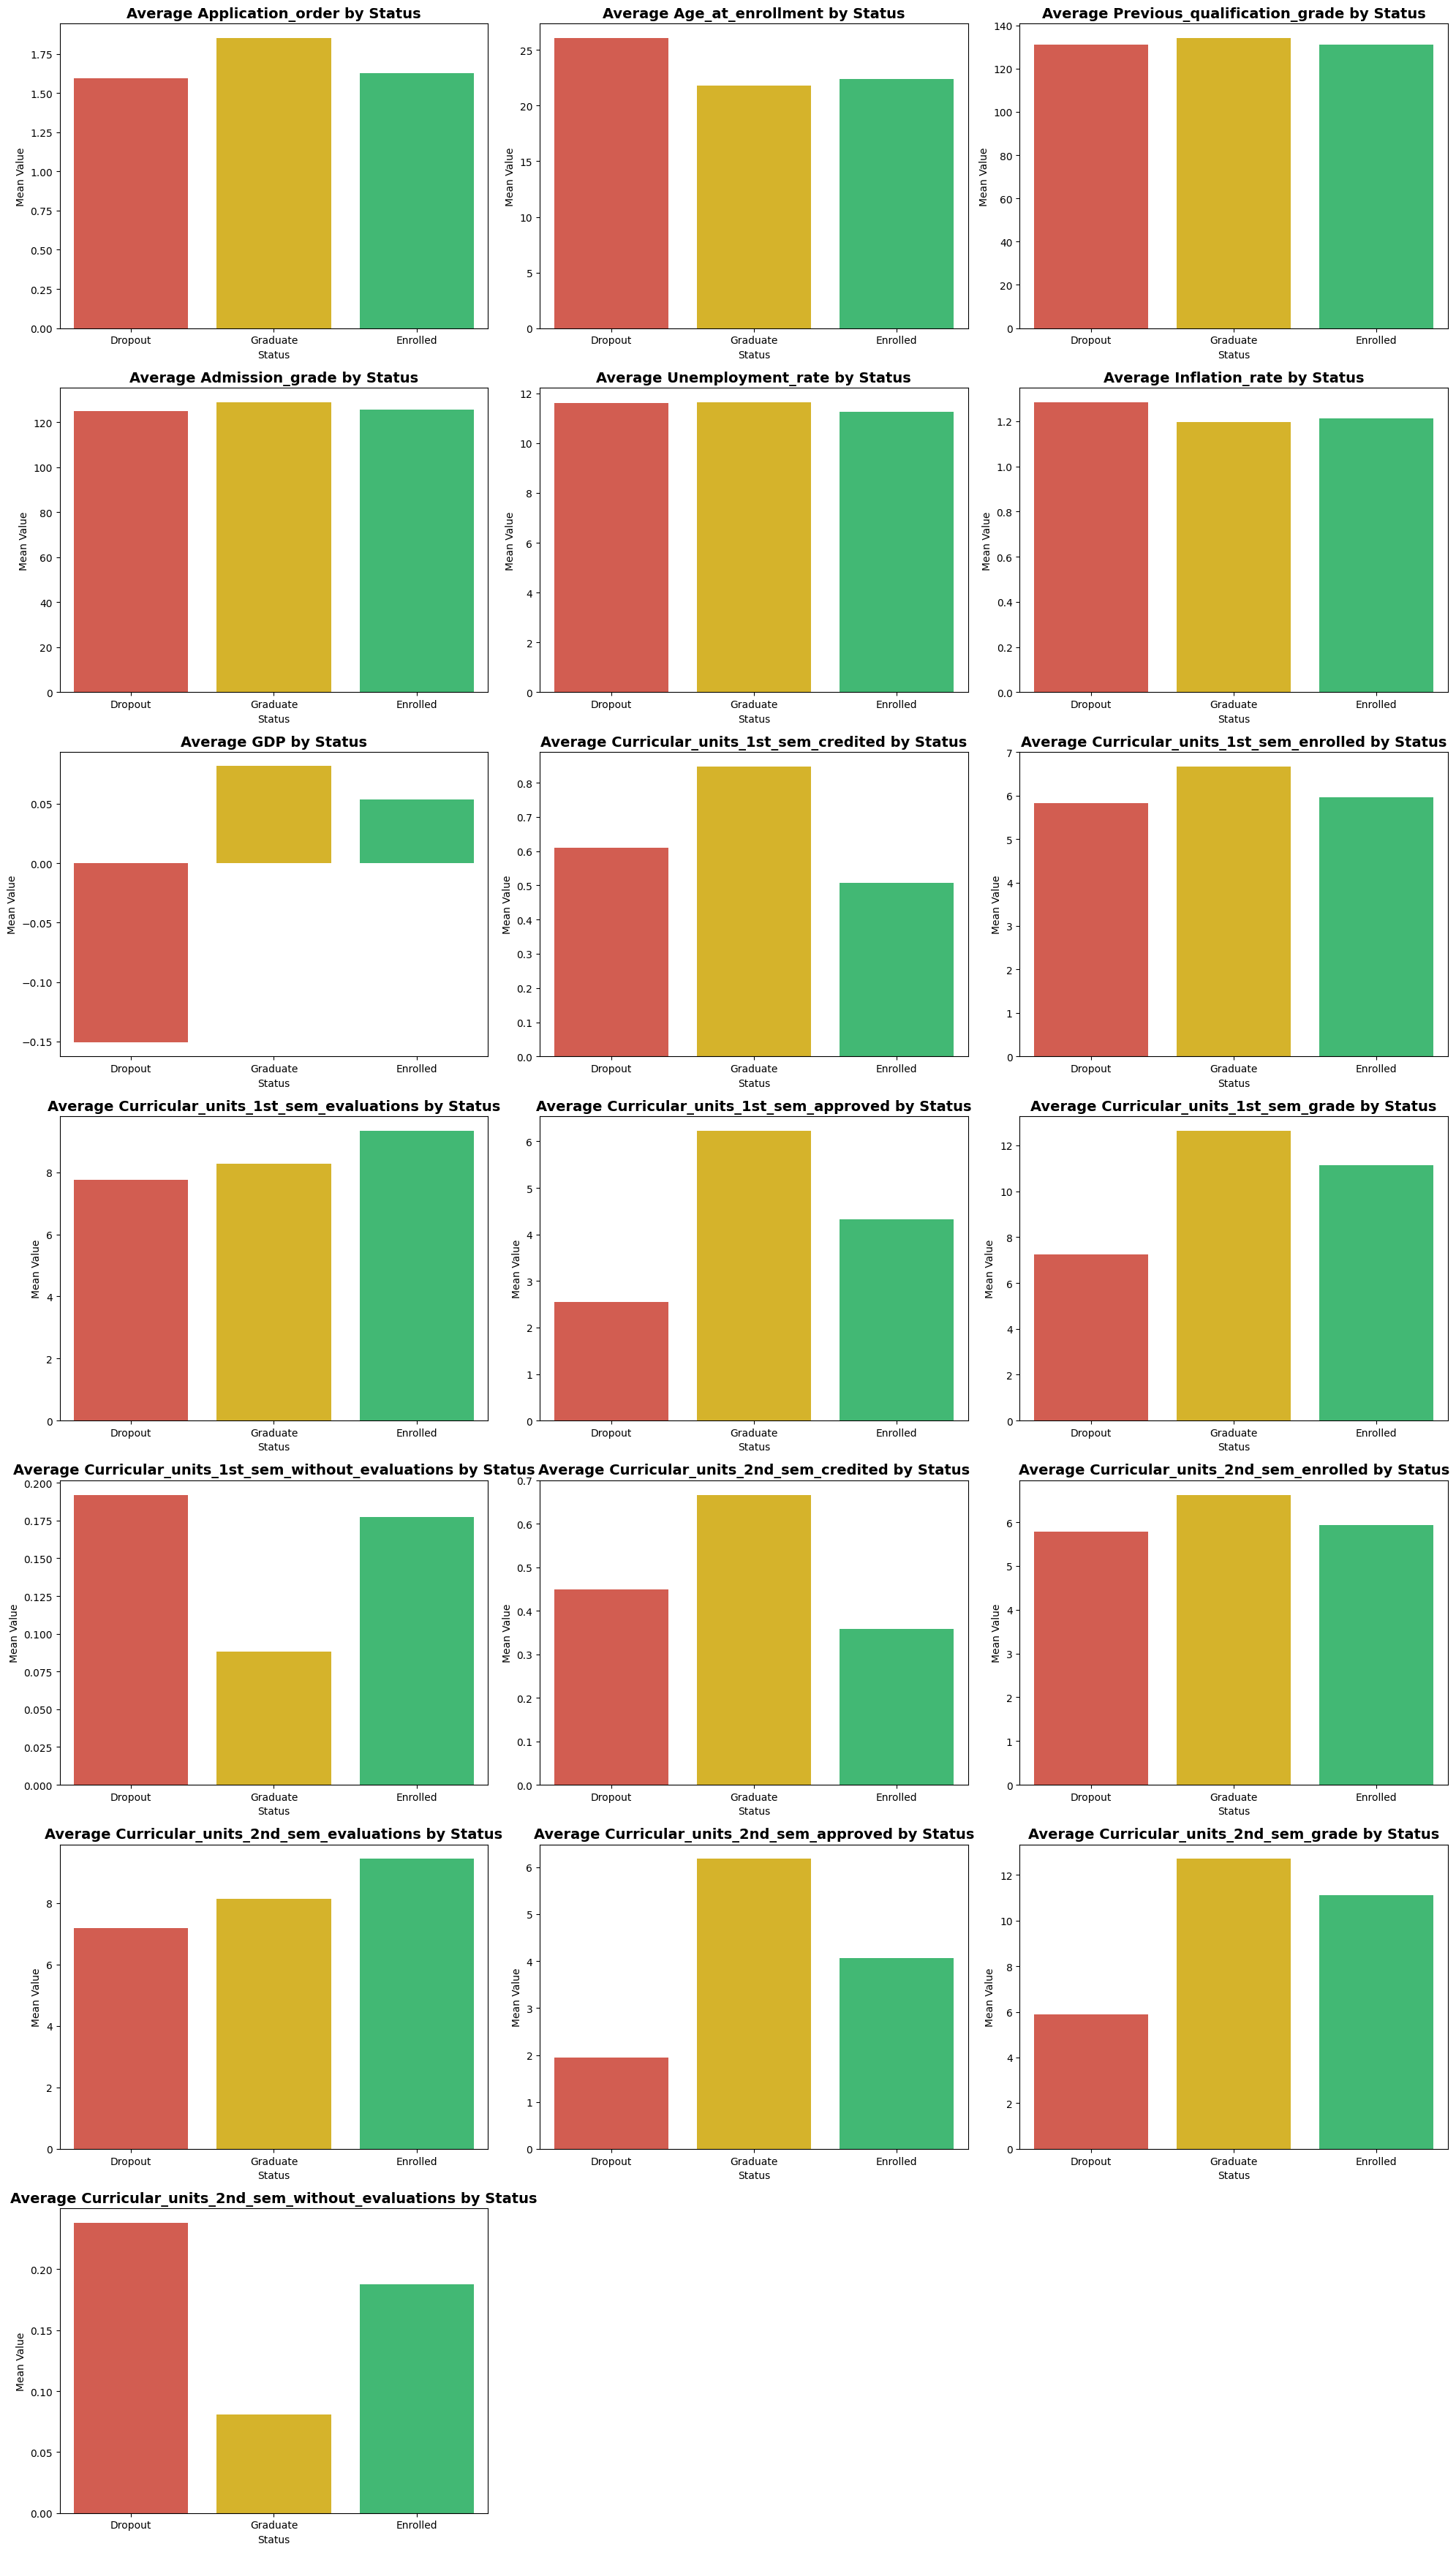

In [12]:
n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.barplot(data=df, 
                x='Status', 
                y=col, 
                ax=axes[i], 
                palette=['#e74c3c', '#f1c40f', '#2ecc71'], 
                hue='Status', 
                legend=False, 
                errorbar=None
                )
    axes[i].set_title(f'Average {col} by Status', 
                        fontsize=14, 
                        fontweight='bold'
                        )
    axes[i].set_xlabel('Status')
    axes[i].set_ylabel('Mean Value')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### EDA Multivariate Fitur Numerik

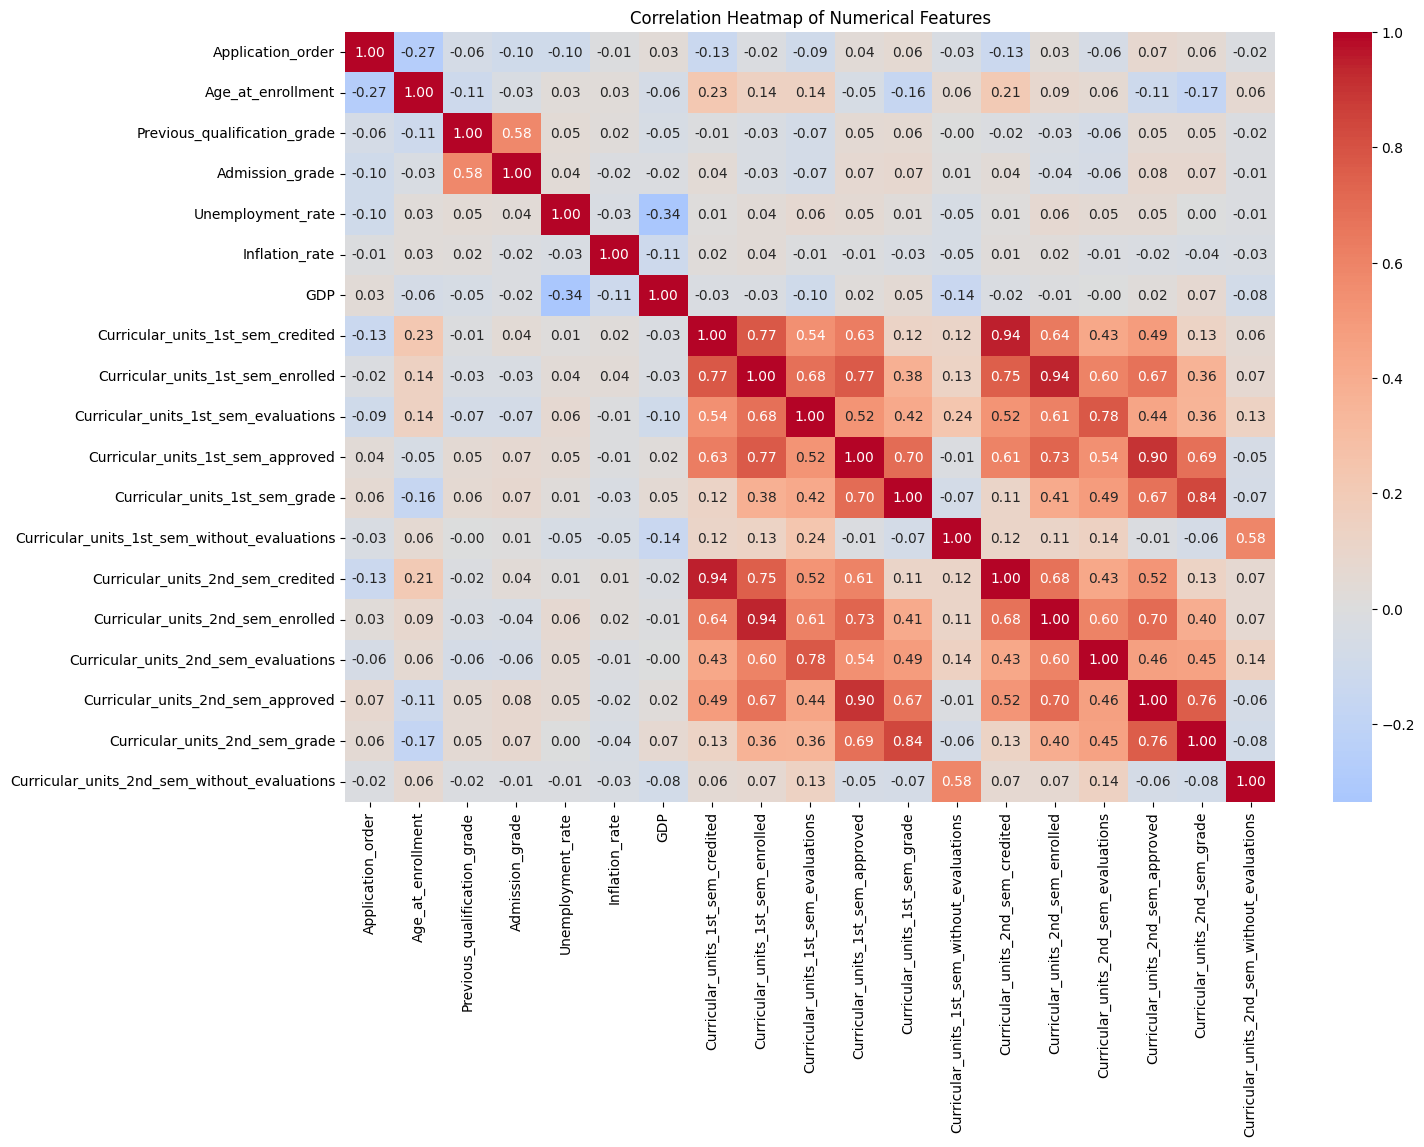

In [13]:
plt.figure(figsize=(15, 10))
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 📊 Ringkasan Temuan Exploratory Data Analysis (EDA)

#### 1. Faktor Finansial sebagai *Red Flag* Utama
Berdasarkan stacked bar plot bivariat, kondisi finansial merupakan prediktor yang sangat kuat terhadap status dropout mahasiswa.

- **Tunggakan SPP (`Tuition_fees_up_to_date`)**  
  Mahasiswa yang menunggak (nilai `0`) memiliki proporsi dropout yang jauh lebih tinggi dibandingkan mahasiswa yang membayar tepat waktu.

- **Status Hutang (`Debtor`)**  
  Mahasiswa dengan status berhutang menunjukkan kecenderungan dropout yang lebih besar.

- **Penerima Beasiswa (`Scholarship_holder`)**  
  Mahasiswa penerima beasiswa memiliki tingkat kelulusan yang sangat dominan, menunjukkan bahwa dukungan finansial berperan krusial dalam keberhasilan akademik.

---

#### 2. Performa Akademik sebagai Penentu Akhir
Bar plot rata-rata fitur numerik menunjukkan perbedaan yang sangat kontras antara mahasiswa lulus dan dropout.

- **Unit Mata Kuliah Disetujui (`Curricular_units_approved`)**  
  Mahasiswa yang lulus memiliki rata-rata unit yang disetujui jauh lebih tinggi di semester 1 dan semester 2.

- **Nilai Akademik (`Curricular_units_grade`)**  
  Terdapat perbedaan yang signifikan antara:
  - Mahasiswa lulus: rata-rata nilai sekitar **12–13**
  - Mahasiswa dropout: rata-rata nilai sekitar **6–7**

Temuan ini mengindikasikan bahwa performa akademik merupakan faktor penentu utama dalam kelulusan mahasiswa.

---

#### 3. Karakteristik Demografi dan Outlier

- **Gender**  
  Terdapat perbedaan proporsi kelulusan yang cukup mencolok antar gender.

- **Usia Saat Pendaftaran (`Age_at_enrollment`)**  
  Ditemukan outlier usia yang cukup ekstrem (hingga ±70 tahun).  
  Rata-rata usia mahasiswa dropout cenderung lebih tinggi dibandingkan mahasiswa yang lulus.

- **Variansi Rendah**  
  Fitur seperti `International` dan `Nacionality` sangat tidak seimbang (didominasi satu kategori), sehingga kurang informatif untuk pemodelan.

---

#### 4. Korelasi dan Redundansi Fitur

- **Multikolinearitas**  
  Terdapat korelasi sangat kuat (> 0.90) antara fitur performa akademik semester 1 dan semester 2, terutama pada:
  - Jumlah unit yang diambil
  - Unit yang disetujui
  - Unit yang diakui

Kondisi ini berpotensi menimbulkan redundansi informasi pada model prediktif.

---

#### 🚀 Strategi Langkah Selanjutnya (*Next Steps*)

#### Langkah 1: Data Cleaning dan Feature Selection
- Hapus fitur dengan variansi sangat rendah seperti:
  - `Nacionality`
  - `International`
  - `Educational_special_needs`

- Tangani fitur redundan dengan:
  - Menggunakan hanya fitur semester 2, atau
  - Menggabungkan fitur semester 1 dan 2 menjadi rata-rata tahunan

---

#### Langkah 2: Preprocessing Data
- **Encoding Target**  
  Gunakan `LabelEncoder` untuk mengubah variabel target `Status` menjadi nilai numerik (0, 1, 2).

- **Feature Scaling**  
  Terapkan `StandardScaler` pada fitur numerik agar perbedaan skala antar fitur menjadi setara.


## Data Preparation / Preprocessing

### Feature Selection

In [14]:
df_model = df.copy()

# --- 1. AVERAGING NUMERICAL FEATURES (Semester 1 & 2) ---
sem_features = ['credited', 'enrolled', 'evaluations', 'approved', 'grade', 'without_evaluations']
for feat in sem_features:
    col_sem1 = f'Curricular_units_1st_sem_{feat}'
    col_sem2 = f'Curricular_units_2nd_sem_{feat}'
    new_col = f'Curricular_units_{feat}_avg'
    df_model[new_col] = (df_model[col_sem1] + df_model[col_sem2]) / 2
    df_model.drop(columns=[col_sem1, col_sem2], inplace=True)

# --- 2. DROPPING CATEGORICAL FEATURES (Low Variance) ---
cat_to_drop = ['Nacionality', 'International', 'Educational_special_needs']
df_model.drop(columns=cat_to_drop, inplace=True)

# --- 3. DROPPING NUMERICAL FEATURES (Low Information) ---
num_to_drop = ['Unemployment_rate', 'Inflation_rate', 'Application_order']
df_model.drop(columns=num_to_drop, inplace=True)

# --- 3.5. DROPPING LOW IMPORTANCE FEATURES (Berdasarkan XGBoost) ---
low_imp_to_drop = [
    'Marital_status', 'Fathers_occupation', 'Daytime_evening_attendance',
    'Mothers_qualification', 'Fathers_qualification'
]
df_model.drop(columns=low_imp_to_drop, inplace=True)

# --- 4. UPDATE LIST FITUR (Hapus fitur yang sudah di-drop dari daftar ini) ---
numerical_features_final = [
    'Age_at_enrollment', 'Previous_qualification_grade', 'Admission_grade', 'GDP',
    'Curricular_units_credited_avg', 'Curricular_units_enrolled_avg',
    'Curricular_units_evaluations_avg', 'Curricular_units_approved_avg',
    'Curricular_units_grade_avg', 'Curricular_units_without_evaluations_avg'
]

# Pastikan fitur yang ada di 'low_imp_to_drop' tidak dimasukkan ke sini lagi
categorical_features_final = [
    'Gender', 'Application_mode', 'Course', 
    'Previous_qualification', 'Mothers_occupation', 
    'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder'
]

target_feature_final = ['Status']

print(f"Jumlah fitur awal: {df.shape[1]}")
print(f"Jumlah fitur setelah selection: {df_model.shape[1]}")
print(f"Fitur numerik akhir: {len(numerical_features_final)}")
print(f"Fitur kategorikal akhir: {len(categorical_features_final)}")
print(f"Fitur target akhir: {len(target_feature_final)}")

#save DataFrame
df_model.to_csv('Datasets/data_preprocessed.csv', index=False)

Jumlah fitur awal: 37
Jumlah fitur setelah selection: 20
Fitur numerik akhir: 10
Fitur kategorikal akhir: 9
Fitur target akhir: 1


### Encoding target

In [15]:
le_target = LabelEncoder()
df_model['Status'] = le_target.fit_transform(df_model['Status'])
target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))

print("=== Mapping Target Status ===")
for label, value in target_mapping.items():
    print(f"{label} -> {value}")
print("==============================")

for col in categorical_features_final:
    le_feat = LabelEncoder()
    df_model[col] = le_feat.fit_transform(df_model[col].astype(str))

print("Chek fitur setelah encoding:")
print(df_model.info())

=== Mapping Target Status ===
Dropout -> 0
Enrolled -> 1
Graduate -> 2
Chek fitur setelah encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Application_mode                          4424 non-null   int32  
 1   Course                                    4424 non-null   int32  
 2   Previous_qualification                    4424 non-null   int32  
 3   Previous_qualification_grade              4424 non-null   float64
 4   Mothers_occupation                        4424 non-null   int32  
 5   Admission_grade                           4424 non-null   float64
 6   Displaced                                 4424 non-null   int32  
 7   Debtor                                    4424 non-null   int32  
 8   Tuition_fees_up_to_date                   4424 non-null   int32  
 9   Gender 

### Spliting Data 

In [16]:
X = df_model.drop(columns=['Status']) 
y = df_model['Status']                

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modeling

In [17]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features_final),
        ('cat', 'passthrough', categorical_features_final) 
    ])

In [18]:
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

trained_pipelines = {}

for name, model in base_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe 

print("✅ Semua model sudah dilatih dan siap divisualisasikan!")

✅ Semua model sudah dilatih dan siap divisualisasikan!


## Evaluation

### Clasification Report (Heat Map)

C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\2872400779.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_plot, ax=axes[row, col], palette='magma')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\2872400779.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_plot, ax=axes[row, col], palette='magma')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\2872400779.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_plot, ax=axes[row, col], palette='

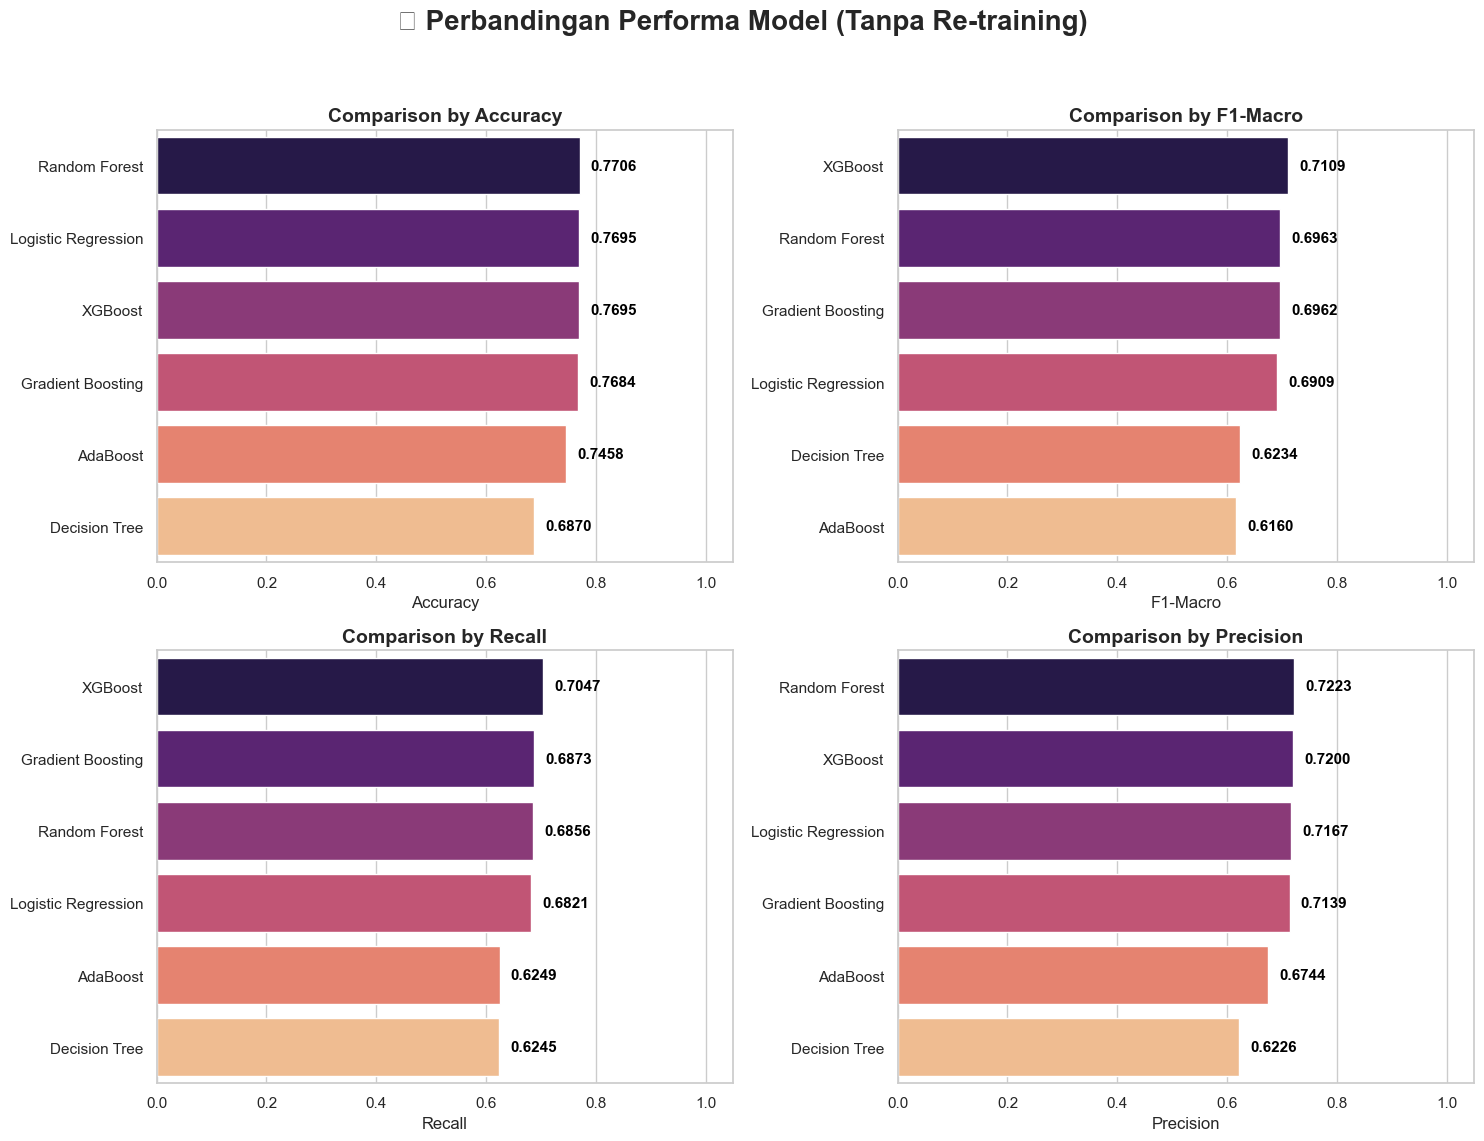

In [19]:
summary_results = []

# Kita ambil pipeline yang sudah 'pintar' dari dictionary hasil training kamu
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate'], output_dict=True)
    
    summary_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': report['macro avg']['f1-score'],
        'Recall': report['macro avg']['recall'],
        'Precision': report['macro avg']['precision']
    })

summary_df = pd.DataFrame(summary_results)

sns.set_theme(style="whitegrid")
metrics = ['Accuracy', 'F1-Macro', 'Recall', 'Precision']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🏆 Perbandingan Performa Model (Tanpa Re-training)', fontsize=20, fontweight='bold')

# Loop untuk membuat barplot di tiap subplot
for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    
    # Mengurutkan agar model terbaik selalu di atas untuk tiap metrik
    df_plot = summary_df.sort_values(metric, ascending=False)
    
    # Gunakan palette 'magma' atau 'viridis' agar terlihat lebih modern
    sns.barplot(x=metric, y='Model', data=df_plot, ax=axes[row, col], palette='magma')
    
    axes[row, col].set_title(f'Comparison by {metric}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlim(0, 1.05) # Beri sedikit ruang di kanan untuk label angka
    axes[row, col].set_xlabel(metric)
    axes[row, col].set_ylabel('') # Hilangkan label Y agar tidak sumpek
    
    # Menambahkan label angka di ujung bar dengan 4 angka di belakang koma
    for p in axes[row, col].patches:
        val = p.get_width()
        axes[row, col].annotate(f'{val:.4f}', 
                                (val, p.get_y() + p.get_height() / 2),
                                ha='left', va='center', 
                                fontsize=11, fontweight='bold',
                                color='black', xytext=(8, 0),
                                textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Confusion Matrix

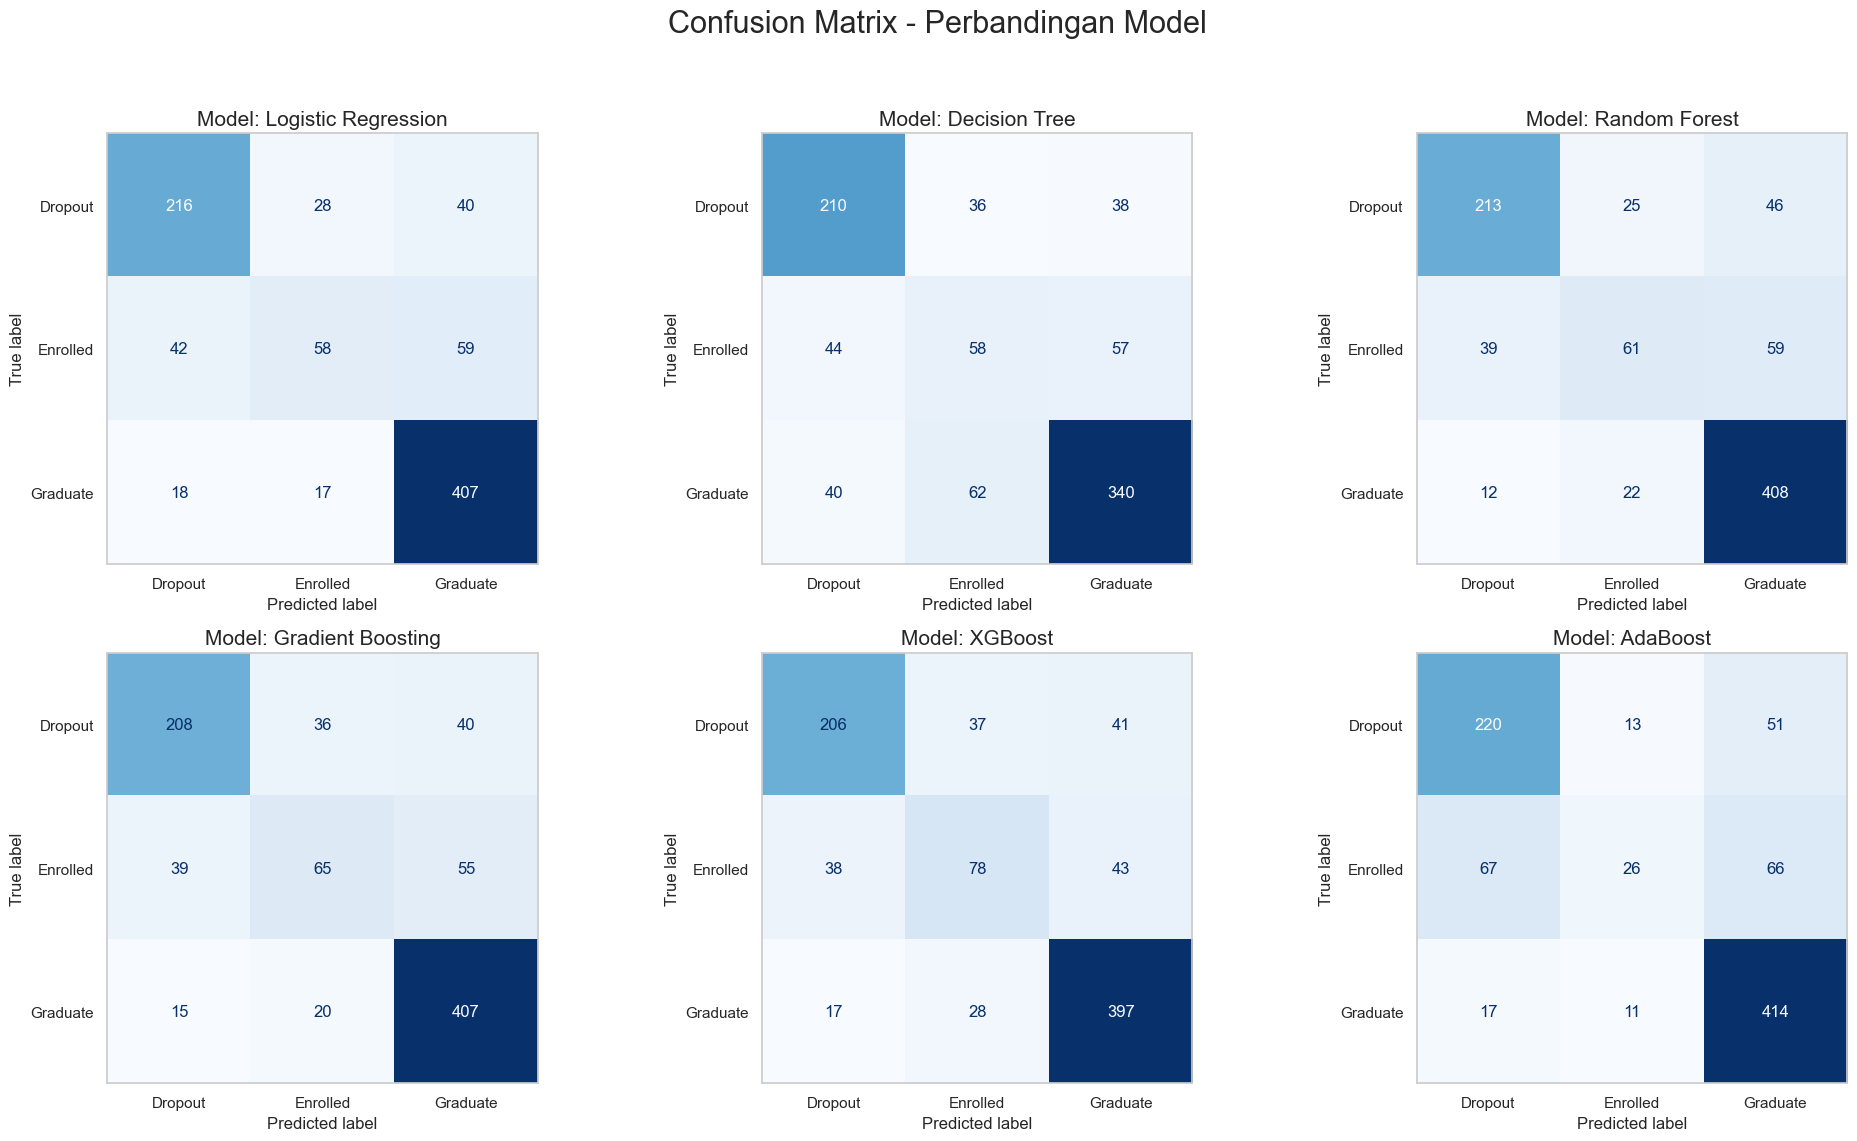

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Confusion Matrix - Perbandingan Model', fontsize=22)

target_names = ['Dropout', 'Enrolled', 'Graduate']

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    row = i // 3
    col = i % 3
    
    y_pred = pipe.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
    
    axes[row, col].set_title(f'Model: {name}', fontsize=15)
    axes[row, col].grid(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Multi-Class ROC-AUC Curve

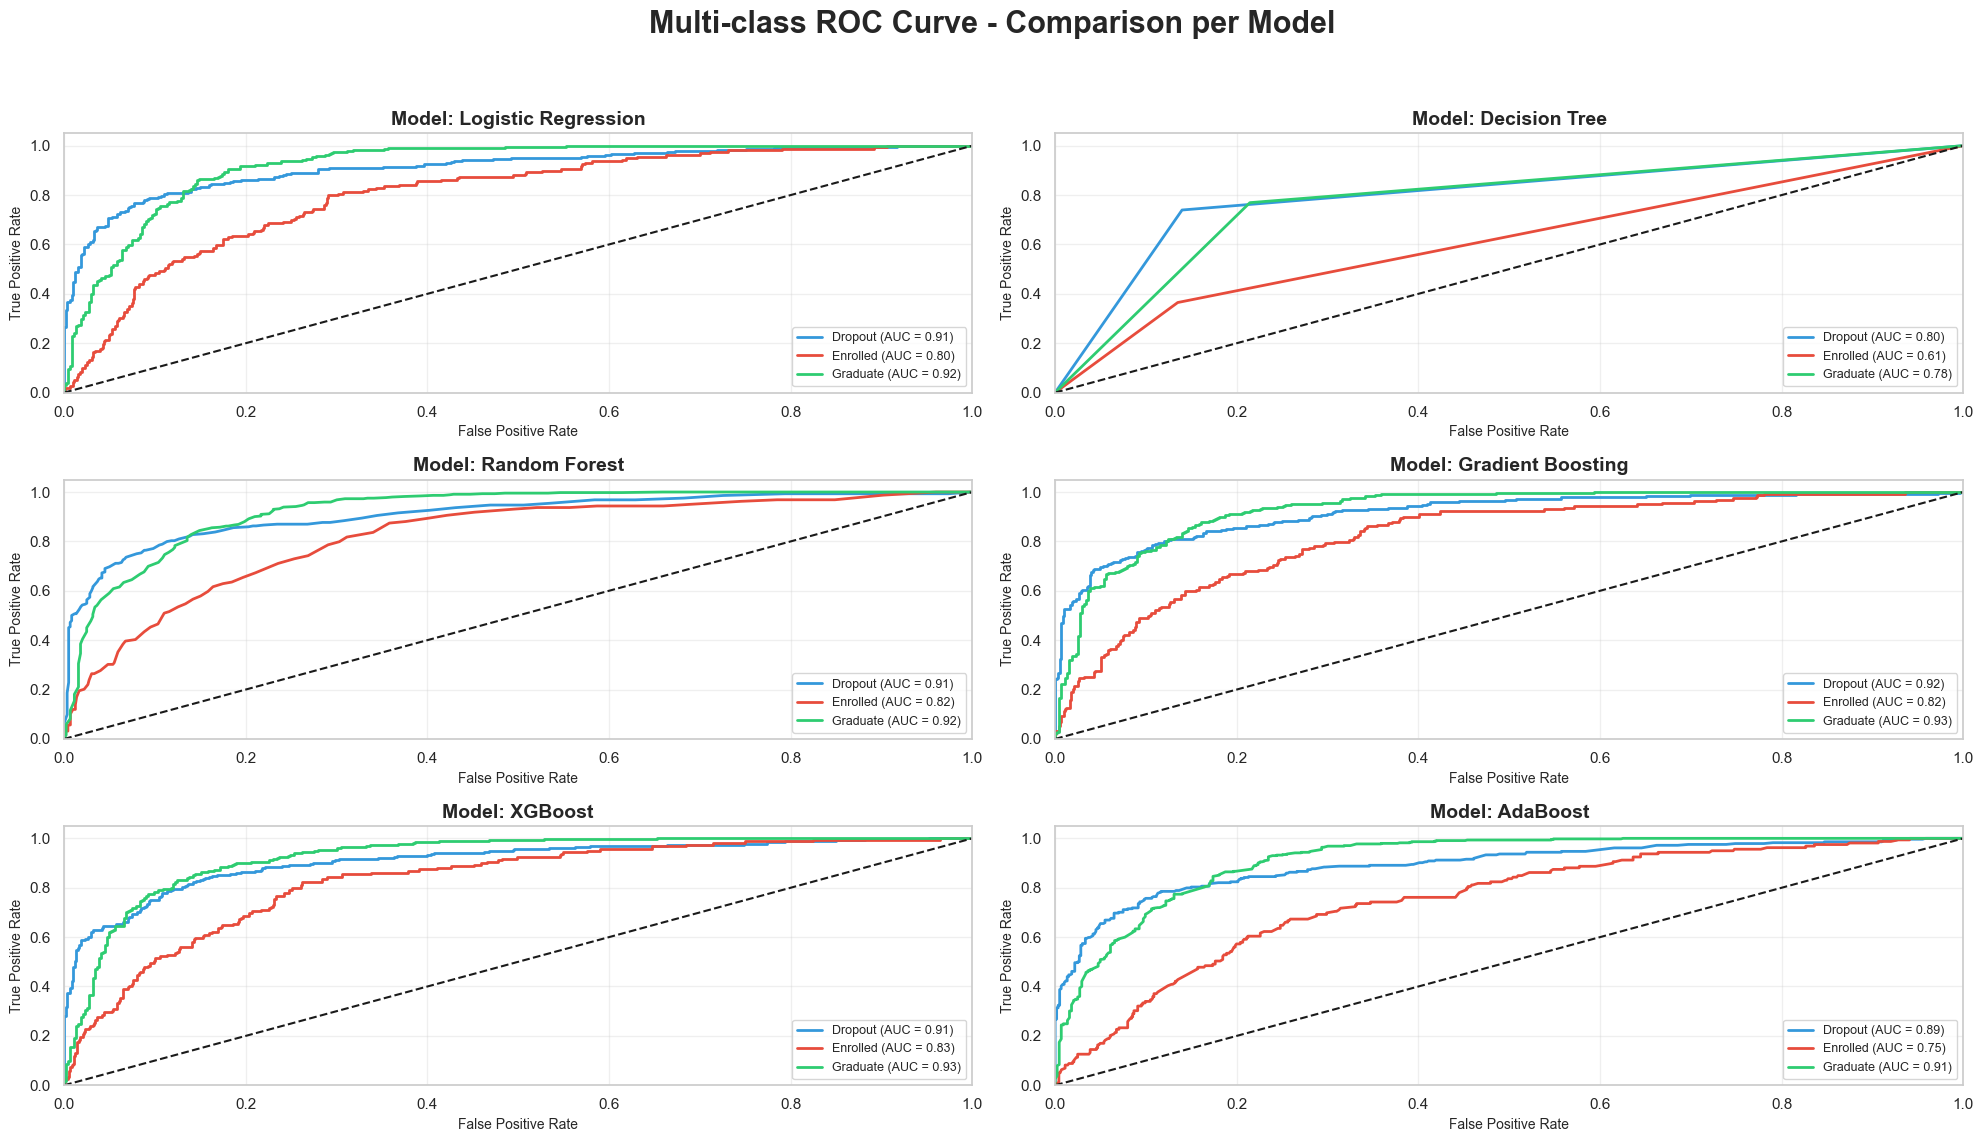

In [21]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
target_names = ['Dropout', 'Enrolled', 'Graduate']
colors = ['#3498db', '#e74c3c', '#2ecc71']
fig, axes = plt.subplots(3, 2, figsize=(20, 12))
fig.suptitle('Multi-class ROC Curve - Comparison per Model', fontsize=22, fontweight='bold')

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    y_score = pipe.predict_proba(X_test)
    
    for j, color in zip(range(3), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, 
                label=f'{target_names[j]} (AUC = {roc_auc:.2f})')
    

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'Model: {name}', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Feature Importance (Final)

C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3850234640.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, ax=ax, palette='magma')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3850234640.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, ax=ax, palette='magma')
C:\Users\Victus\AppData\Local\Temp\ipykernel_4196\3850234640.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, ax=ax, palette='magma')
C:\User

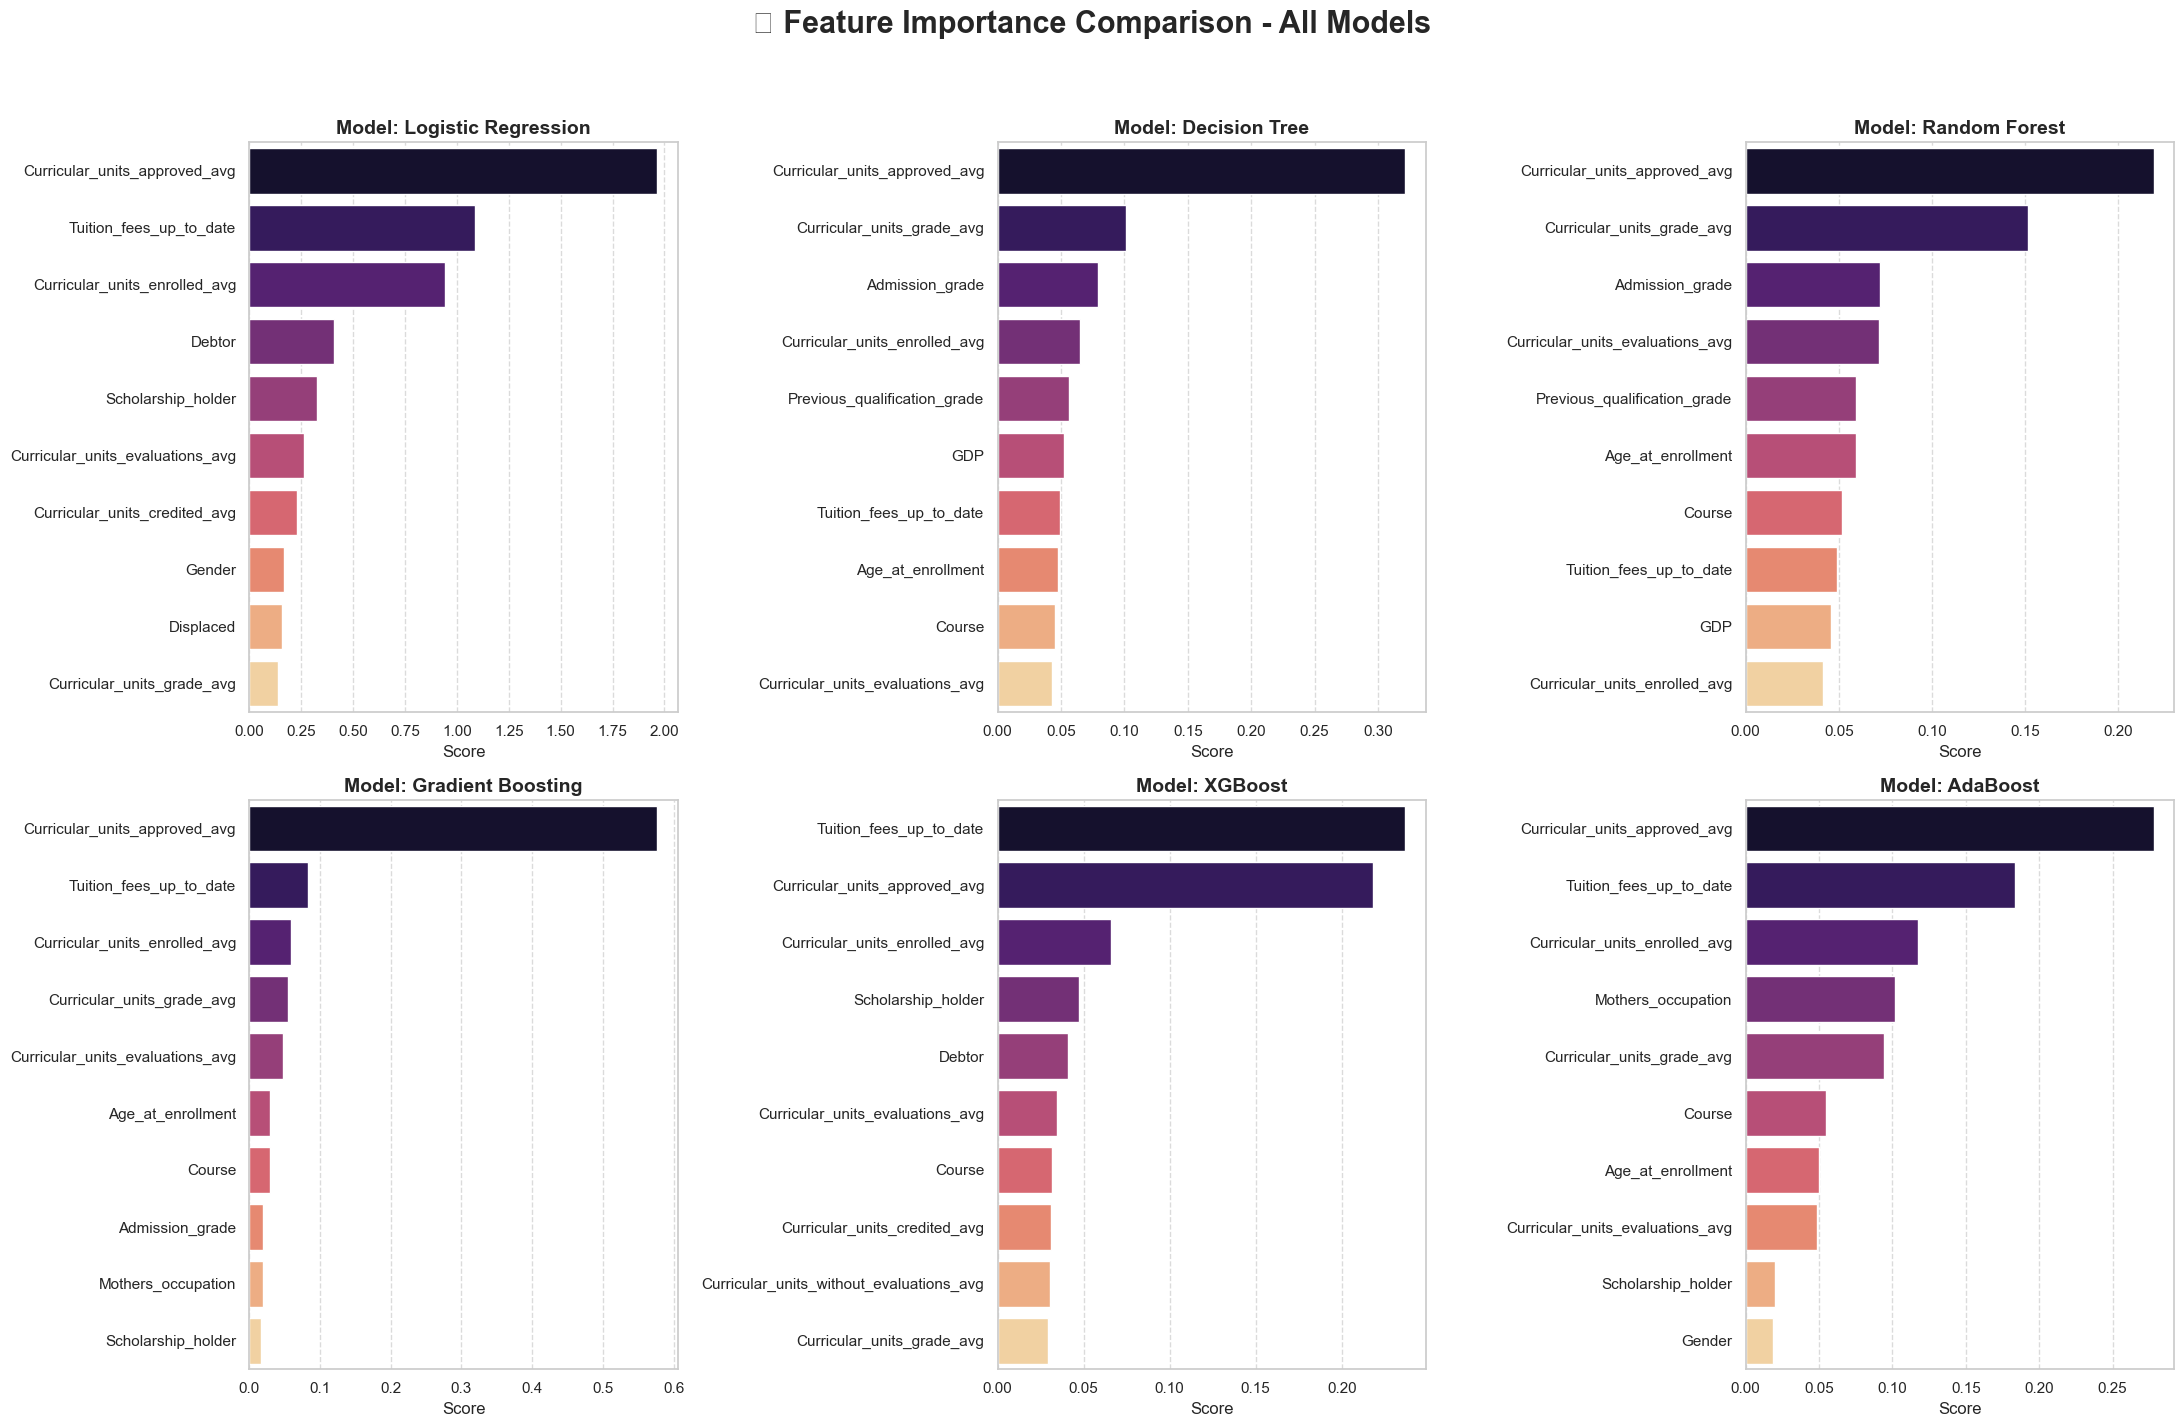

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(22, 15))
fig.suptitle('🔍 Feature Importance Comparison - All Models', fontsize=22, fontweight='bold')
feature_names = numerical_features_final + categorical_features_final

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    model_step = pipe.named_steps['model']
    
    if hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
    elif hasattr(model_step, 'coef_'):
        importances = np.mean(np.abs(model_step.coef_), axis=0)
    else:
        continue 
        
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(10) 

    # Plotting
    sns.barplot(x='Importance', y='Feature', data=df_imp, ax=ax, palette='magma')
    
    ax.set_title(f'Model: {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Atur tata letak
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 🏆 Kesimpulan Akhir: Pemilihan Model XGBoost

Pemilihan **XGBoost** didasarkan pada performanya yang paling **stabil dan unggul** pada metrik-metrik kunci yang krusial untuk menangani **imbalanced data (data tidak seimbang)** pada dataset ini.

---

#### 1️⃣ Dominasi Metrik Performa Utama

Berdasarkan visualisasi perbandingan metrik evaluasi, **XGBoost** menempati peringkat teratas pada dua metrik paling penting:

- **F1-Macro (0.7109)**  
  Metrik terbaik untuk menilai keseimbangan performa model pada seluruh kelas (*Dropout, Enrolled, Graduate*).  
  XGBoost unggul dibandingkan:
  - Random Forest (0.6963)
  - Gradient Boosting (0.6962)

- **Recall (0.7047)**  
  Menunjukkan kemampuan model dalam menangkap sebanyak mungkin mahasiswa yang berisiko **Dropout**.  
  Nilai ini merupakan yang **tertinggi** dibandingkan model lainnya.

- **Accuracy (0.7695)**  
  Berada pada posisi yang sangat kompetitif, dengan selisih yang sangat tipis terhadap Random Forest (0.7706), sehingga menunjukkan keandalan prediksi secara keseluruhan.

---

#### 2️⃣ Kemampuan Klasifikasi  
*(Confusion Matrix & ROC Analysis)*

Analisis mendalam terhadap performa klasifikasi menunjukkan keunggulan XGBoost sebagai berikut:

- **Akurasi Kelas *Enrolled***  
  Berdasarkan *Confusion Matrix*, XGBoost mampu memprediksi kelas **Enrolled** dengan benar sebanyak **78 data**, lebih tinggi dibandingkan:
  - Random Forest (61)
  - Logistic Regression (58)  

  Hal ini menunjukkan bahwa XGBoost lebih peka terhadap kelas yang paling sulit diprediksi.

- **Stabilitas AUC (ROC Curve)**  
  Kurva ROC menunjukkan performa pemisahan kelas yang sangat baik:
  - **AUC Graduate: 0.93**
  - **AUC Dropout: 0.91**

  Nilai AUC yang mendekati **1.0** menandakan kemam


## Save model

In [23]:
if not os.path.exists('models'):
    os.makedirs('models')

xgb_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('xgb', XGBClassifier(random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_final = xgb_pipeline.predict(X_test)
target_names = ['Dropout', 'Enrolled', 'Graduate']
report_final = classification_report(y_test, y_pred_final, target_names=target_names, digits=4)

print("\n=== EVALUASI FINAL XGBOOST ===")
print("-" * 45)
print(report_final)

joblib.dump(xgb_pipeline, 'models/model_student_dropout.pkl')
print("\n✅ Model berhasil disimpan di: models/model_student_dropout.pkl")


=== EVALUASI FINAL XGBOOST ===
---------------------------------------------
              precision    recall  f1-score   support

     Dropout     0.7893    0.7254    0.7560       284
    Enrolled     0.5455    0.4906    0.5166       159
    Graduate     0.8254    0.8982    0.8602       442

    accuracy                         0.7695       885
   macro avg     0.7200    0.7047    0.7109       885
weighted avg     0.7635    0.7695    0.7650       885


✅ Model berhasil disimpan di: models/model_student_dropout.pkl
